In [ ]:
%pip install tensorflow==2.15
# %pip install keras_applications
# %pip install git+https://github.com/rcmalli/keras-vggface.git
import os
import tarfile
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
import matplotlib.pyplot as plt
import cv2

print("TensorFlow Version:", tf.__version__)

IMG_SIZE = 224
CLASS_LABELS = ['neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt']
BASE_OUTPUT_DIR = "/kaggle/working/xai_results"

if os.path.exists(BASE_OUTPUT_DIR):
    shutil.rmtree(BASE_OUTPUT_DIR)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 3.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 47.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 5.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 68.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 4.7 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstalling wrapt-1.17.2:
      Successfully uninstalled wrapt-1.17.2
  Attempting uninstall: keras
    Found existing installation: keras 3.8.0
    Uninstalling keras-3.8.0:
      Successfully uninstalled keras-3.8.0
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
  Attempting uninstal

2025-11-09 22:08:45.351237: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-09 22:08:45.351319: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-09 22:08:45.353727: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow Version: 2.15.0


In [ ]:
print("\n--- Carregando o Modelo ---")

model_path = '/kaggle/input/newdatasetvggresnet50ferplus/model_v2_fase1_head_only.h5'

print(f"Tentando carregar o modelo do caminho: {model_path}")

try:
    model = tf.keras.models.load_model(model_path)
    model.compile(metrics=['accuracy'])
    model.summary()
except Exception as e:
    print(f"Erro ao carregar o modelo: {e}")
    raise

BASE_MODEL_NAME = 'vggface_resnet50'
LAST_CONV_LAYER_NAME = "activation_48"


--- Carregando o Modelo ---
Tentando carregar o modelo do caminho: /kaggle/input/newdatasetvggresnet50ferplus/model_v2_fase1_head_only.h5
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vggface_resnet50 (Function  (None, 1, 1, 2048)        23561152  
 al)                                                             
                                                                 
 flatten (Flatten)           (None, 2048)              0         
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 2048)              4196352   
                                                                 
 dropout_1 (Dropout)         (None, 2048)              0         
                                                 

In [ ]:
print("\n--- Carregando e Preparando os Dados a partir de Diretórios ---")

TEST_DATA_DIR = '/kaggle/input/fer2013plus/fer2013plus/fer2013/test'

if not os.path.exists(TEST_DATA_DIR):
    raise FileNotFoundError(f"O diretório de teste não foi encontrado em: {TEST_DATA_DIR}")


test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DATA_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    interpolation='bilinear',
    batch_size=32,
    shuffle=False
)

CLASS_LABELS = test_dataset.class_names
print("Classes encontradas:", CLASS_LABELS)

def normalize_img(image, label):
    return image / 255.0, label

normalized_dataset = test_dataset.map(normalize_img)

filepaths = test_dataset.file_paths
true_labels = np.concatenate([y for x, y in test_dataset], axis=0)

print(f"{len(filepaths)} imagens de teste carregadas e preparadas.")


--- Carregando e Preparando os Dados a partir de Diretórios ---
Found 7099 files belonging to 8 classes.
Classes encontradas: ['anger', 'contempt', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
7099 imagens de teste carregadas e preparadas.


In [ ]:
print("\n--- Definindo as Funções XAI ---")

def preprocess_input_vggface(x, version=2):
    """Pré-processa um tensor ou array numpy para o VGGFace."""
    x_temp = np.copy(x)
    if version == 1:
        x_temp = x_temp[..., ::-1]
        x_temp[..., 0] -= 93.5940
        x_temp[..., 1] -= 104.7624
        x_temp[..., 2] -= 129.1863
    elif version == 2:
        x_temp = x_temp[..., ::-1]
        x_temp[..., 0] -= 91.4953
        x_temp[..., 1] -= 103.8827
        x_temp[..., 2] -= 131.0912
    else:
        raise ValueError("A versão deve ser 1 ou 2.")
    return x_temp

def load_and_preprocess_single_image(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.utils.img_to_array(img)
    
    img_expanded = np.expand_dims(img_array, axis=0)
    
    return preprocess_input_vggface(img_expanded, version=2)

def get_gradcam(model, img_array, last_conv_activation_layer_name, class_index=None):
    try:
        print(f"[Debug Grad-CAM] Procurando base_model: '{BASE_MODEL_NAME}'")
        base_model = model.get_layer(BASE_MODEL_NAME)
    except ValueError:
        raise ValueError(f"Modelo base com nome '{BASE_MODEL_NAME}' não encontrado.")

    target_conv_layer = None
    for layer in reversed(base_model.layers):
        if layer.name == last_conv_activation_layer_name:
            continue
        if target_conv_layer is None and isinstance(layer, tf.keras.layers.Conv2D):
            target_conv_layer = layer
            break
    
    if target_conv_layer is None:
        raise ValueError(f"Não foi possível encontrar uma camada Conv2D antes de '{last_conv_activation_layer_name}'")
    
    print(f"INFO (Grad-CAM): A partir de '{last_conv_activation_layer_name}', o alvo para o gradiente foi definido como: '{target_conv_layer.name}'")
    
    original_trainable_state = base_model.trainable
    base_model.trainable = True
    
    try:
        base_model_index = model.layers.index(base_model)
        top_model_layers = model.layers[base_model_index + 1:]
        
        grad_model_inputs = base_model.inputs
        
        conv_output_symbolic = target_conv_layer.output
        
        x = base_model.output
        for layer in top_model_layers:
            x = layer(x)
        final_logits_symbolic = x

        grad_model = tf.keras.models.Model(
            inputs=grad_model_inputs, 
            outputs=[conv_output_symbolic, final_logits_symbolic]
        )
        
        with tf.GradientTape() as tape:
            last_conv_layer_output, logits = grad_model(img_array)
            tape.watch(last_conv_layer_output) 
            
            if class_index is None:
                class_index = tf.argmax(logits[0])
            
            class_channel = logits[:, class_index]
            
        grads = tape.gradient(class_channel, last_conv_layer_output)
        
        if grads is None: return np.array([])
        
        grads = tf.cast(grads, tf.float32)
        last_conv_layer_output = tf.cast(last_conv_layer_output, tf.float32)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)
        heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-7)

        return heatmap.numpy()

    finally:
        base_model.trainable = original_trainable_state

def get_score_cam(model, img_array, layer_name, class_index):
    img_array = tf.cast(img_array, dtype=tf.float32)
    base_model = model.get_layer(BASE_MODEL_NAME)
    
    conv_output = base_model.get_layer(layer_name).output

    feature_map_model = Model(
        inputs=base_model.inputs, 
        outputs=conv_output
    )
    
    feature_maps = feature_map_model.predict(img_array, verbose=0)
    feature_maps = tf.cast(feature_maps, dtype=tf.float32)
    masks = tf.image.resize(feature_maps, (IMG_SIZE, IMG_SIZE), method='bilinear')
    masks = tf.reshape(masks, (-1, IMG_SIZE, IMG_SIZE))
    min_vals = tf.reduce_min(masks, axis=[1, 2], keepdims=True)
    max_vals = tf.reduce_max(masks, axis=[1, 2], keepdims=True)
    masks = (masks - min_vals) / (max_vals - min_vals + 1e-7)
    masked_images = tf.expand_dims(img_array[0], axis=0) * tf.expand_dims(masks, axis=-1)
    
    logits = model.predict(masked_images, verbose=0)
    probs = tf.nn.softmax(tf.cast(logits, tf.float32))
    scores = probs[:, class_index].numpy()
    
    heatmap = tf.einsum('ijk,k->ij', tf.squeeze(feature_maps), scores)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = (heatmap - tf.reduce_min(heatmap)) / (tf.reduce_max(heatmap) - tf.reduce_min(heatmap) + 1e-7)
    return heatmap.numpy()

def get_integrated_gradients(model, img_array, class_index, m_steps=50):
    try:
        base_model = model.get_layer(BASE_MODEL_NAME)
    except ValueError:
        raise ValueError(f"Modelo base com nome '{BASE_MODEL_NAME}' não encontrado.")

    original_trainable_state = base_model.trainable
    base_model.trainable = True

    try:
        baseline = tf.zeros_like(img_array)
        interpolated_images = tf.concat(
            [baseline + (float(i) / m_steps) * (img_array - baseline) for i in range(m_steps + 1)],
            axis=0
        )

        with tf.GradientTape() as tape:
            tape.watch(interpolated_images)
            logits = model(interpolated_images, training=False)
            predictions = tf.cast(logits, tf.float32) 
            top_class_predictions = predictions[:, class_index]

        grads = tape.gradient(top_class_predictions, interpolated_images)

        if grads is None:
            print("AVISO (IG): O gradiente é None.")
            return np.zeros((IMG_SIZE, IMG_SIZE))

        avg_grads = tf.reduce_mean(grads, axis=0)
        integrated_gradients = (img_array - baseline) * avg_grads
        
        heatmap = tf.reduce_sum(tf.math.abs(integrated_gradients), axis=-1)
        heatmap_np = np.squeeze(heatmap.numpy())
        
        min_val, max_val = np.min(heatmap_np), np.max(heatmap_np)
        
        if max_val - min_val < 1e-7:
            print("AVISO (IG): O heatmap gerado é plano (sem variação). Retornando zeros.")
            return np.zeros_like(heatmap_np)
            
        heatmap_np = (heatmap_np - min_val) / (max_val - min_val)
        return heatmap_np

    finally:
        base_model.trainable = original_trainable_state

@tf.function
def get_batch_predictions_rise(model, masked_images):
    logits = model(masked_images, training=False)
    probs = tf.nn.softmax(tf.cast(logits, tf.float32))
    return probs
    
def get_rise(model, img_array, class_index, N=2000, s=8, p1=0.5, batch_size=50):
    heatmap = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
    img_tensor = tf.cast(img_array, dtype=tf.float32)

    for i in range(0, N, batch_size):
        num_masks_in_batch = min(batch_size, N - i)
        masks = np.random.choice([0, 1], size=(num_masks_in_batch, s, s), p=[1 - p1, p1])
        masks_tensor = tf.cast(masks, dtype=tf.float32)
        upsampled_masks = tf.image.resize(tf.expand_dims(masks_tensor, -1), (IMG_SIZE, IMG_SIZE), method='bilinear')
        
        masked_images = img_tensor * upsampled_masks
        predictions = get_batch_predictions_rise(model, masked_images)
        
        confidences = predictions[:, class_index]
        
        current_heatmap_sum = tf.reduce_sum(upsampled_masks * confidences[:, tf.newaxis, tf.newaxis, tf.newaxis], axis=0)
        heatmap += current_heatmap_sum.numpy().squeeze()
        
    heatmap /= N
    heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap) + 1e-7)
    return heatmap

def superimpose_heatmap(img_array_orig, heatmap, alpha=0.5, colormap=cv2.COLORMAP_JET):
    img = np.squeeze(img_array_orig)
    if img.max() <= 1.0:
        img = np.uint8(255 * img)
    img = img.astype(np.uint8)

    if heatmap is None or not isinstance(heatmap, np.ndarray) or heatmap.size == 0:
        print(f"AVISO (superimpose_heatmap): Heatmap inválido recebido. Retornando imagem original.")
        if len(img.shape) == 2 or img.shape[2] == 1:
            return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        return img

    try:
        heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    except cv2.error as e:
        print(f"AVISO (superimpose_heatmap): erro no cv2.resize. Retornando imagem original. Erro: {e}")
        if len(img.shape) == 2 or img.shape[2] == 1:
            return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        return img
        
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    jet = cv2.applyColorMap(heatmap_uint8, colormap)
    jet_rgb = cv2.cvtColor(jet, cv2.COLOR_BGR2RGB)

    superimposed_img = cv2.addWeighted(img, 1 - alpha, jet_rgb, alpha, 0)
    
    return superimposed_img

xai_methods = {
    "Grad-CAM": get_gradcam,
    "RISE": get_rise,
    "Score-CAM": get_score_cam,
    "Integrated_Gradients": get_integrated_gradients,
}


--- Definindo as Funções XAI ---


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

print("\n--- INICIANDO AVALIAÇÃO COM PIPELINE DE DADOS CORRIGIDO ---")

def preprocess_input_vggface(x, version=2):
    x_temp = x.astype('float32')
    if version == 2:
        x_temp = x_temp[..., ::-1]
        x_temp[..., 0] -= 91.4953
        x_temp[..., 1] -= 103.8827
        x_temp[..., 2] -= 131.0912
    else:
        raise ValueError("Esta função está configurada apenas para a versão 2 (ResNet50).")
    return x_temp

test_dataset_unbatched = tf.keras.utils.image_dataset_from_directory(
    TEST_DATA_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    interpolation='bilinear',
    batch_size=None,
    shuffle=False
)

def map_preprocess_vggface(image, label):
    [processed_image,] = tf.py_function(
        lambda img: preprocess_input_vggface(img.numpy()),
        [image],
        [tf.float32]
    )
    processed_image.set_shape((IMG_SIZE, IMG_SIZE, 3))
    return processed_image, label


--- INICIANDO AVALIAÇÃO COM PIPELINE DE DADOS CORRIGIDO ---
Found 7099 files belonging to 8 classes.


In [ ]:
processed_dataset = test_dataset_unbatched.map(map_preprocess_vggface)

normalized_dataset = processed_dataset.batch(32) # Usamos um batch_size padrão

filepaths = test_dataset_unbatched.file_paths
true_labels = np.array([label for img, label in test_dataset_unbatched])
class_names_xai = test_dataset_unbatched.class_names

all_logits = model.predict(normalized_dataset)
all_preds = tf.nn.softmax(all_logits, axis=1).numpy()
predicted_labels_treino = np.argmax(all_preds, axis=1)

training_order = ['neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt']
remap_index = {training_order.index(emotion): class_names_xai.index(emotion) for emotion in training_order}
predicted_labels_corrigido = np.array([remap_index[p] for p in predicted_labels_treino])

accuracy = accuracy_score(true_labels, predicted_labels_corrigido)
print(f"\nPRECISÃO GERAL REAL NO CONJUNTO DE TESTE: {accuracy:.4f} ({accuracy * 100:.2f}%)")
print("\n--- Relatório de Classificação Detalhado ---")
print(classification_report(true_labels, predicted_labels_corrigido, target_names=class_names_xai, zero_division=0))

print("\n--- Preparando listas de sucessos e falhas com dados corrigidos ---")
analysis_data = []
for i in range(len(filepaths)):
    analysis_data.append({
        'filepath': filepaths[i],
        'true_label_idx': true_labels[i],
        'pred_label_idx': predicted_labels_corrigido[i],
        'confidence': np.max(all_preds[i])
    })

sucessos = [item for item in analysis_data if item['true_label_idx'] == item['pred_label_idx']]
falhas = [item for item in analysis_data if item['true_label_idx'] != item['pred_label_idx']]

print(f"Listas de análise recriadas: {len(sucessos)} sucessos, {len(falhas)} falhas.")
print("Agora você pode prosseguir com a geração dos exemplos de XAI.")

222/222 [==============================] - 915s 4s/step

PRECISÃO GERAL REAL NO CONJUNTO DE TESTE: 0.7522 (75.22%)

--- Relatório de Classificação Detalhado ---
              precision    recall  f1-score   support

       anger       0.72      0.71      0.71       644
    contempt       0.45      0.33      0.38        51
     disgust       0.44      0.56      0.50        57
        fear       0.40      0.62      0.48       167
   happiness       0.83      0.90      0.86      1827
     neutral       0.81      0.74      0.78      2597
     sadness       0.56      0.57      0.57       856
    surprise       0.77      0.75      0.76       900

    accuracy                           0.75      7099
   macro avg       0.62      0.65      0.63      7099
weighted avg       0.76      0.75      0.75      7099


--- Preparando listas de sucessos e falhas com dados corrigidos ---
Listas de análise recriadas: 5340 sucessos, 1759 falhas.
Agora você pode prosseguir com a geração dos exemplos de XAI.


In [ ]:
print("\n--- Gerando e Salvando Heatmaps Individuais (Agrupado por Método) ---")

N_EXAMPLES_TO_SAVE = 4

def deprocess_input_vggface(x):
    x_temp = x.copy()
    if len(x_temp.shape) == 4 and x_temp.shape[0] == 1:
        x_temp = x_temp[0, ...]
    x_temp[..., 0] += 91.4953
    x_temp[..., 1] += 103.8827
    x_temp[..., 2] += 131.0912
    x_temp = x_temp[..., ::-1]
    x_temp = np.clip(x_temp, 0, 255).astype('uint8')
    return x_temp

In [ ]:
analysis_output_dir = os.path.join(BASE_OUTPUT_DIR, "Analise_Individual_Heatmaps")
os.makedirs(analysis_output_dir, exist_ok=True)

analysis_cases_to_save = {
    "A_Sucessos_Canonicos": sucessos[:N_EXAMPLES_TO_SAVE],
    "B_Falhas_Interessantes": falhas[:N_EXAMPLES_TO_SAVE],
}
print(f"Resultados individuais serão salvos em: {analysis_output_dir}")

print("\n--- Pré-processando e salvando imagens originais ---")
for category_name, cases in analysis_cases_to_save.items():
    for i, case_info in enumerate(cases):
        true_label_name = class_names_xai[case_info['true_label_idx']]
        pred_label_name = class_names_xai[case_info['pred_label_idx']]
        image_id = os.path.splitext(os.path.basename(case_info['filepath']))[0]
        
        image_output_dir_name = f"{i+1}_True-{true_label_name}_Pred-{pred_label_name}_{image_id}"
        image_output_dir_path = os.path.join(analysis_output_dir, category_name, image_output_dir_name)
        os.makedirs(image_output_dir_path, exist_ok=True)
        
        img_array = load_and_preprocess_single_image(case_info['filepath'])
        original_img_display = deprocess_input_vggface(img_array)
        original_save_path = os.path.join(image_output_dir_path, "0_Original.png")
        plt.imsave(original_save_path, original_img_display, cmap='gray')


for j, (method_name, method_func) in enumerate(xai_methods.items()):
    print(f"\n===== Gerando Heatmaps para o Método: {method_name} =====")
    
    for category_name, cases in analysis_cases_to_save.items():
        print(f"  - Processando categoria: {category_name}")
        
        for i, case_info in enumerate(cases):
            
            true_label_name = class_names_xai[case_info['true_label_idx']]
            pred_label_name = class_names_xai[case_info['pred_label_idx']]
            image_id = os.path.splitext(os.path.basename(case_info['filepath']))[0]
            
            image_output_dir_name = f"{i+1}_True-{true_label_name}_Pred-{pred_label_name}_{image_id}"
            image_output_dir_path = os.path.join(analysis_output_dir, category_name, image_output_dir_name)
            
            img_array = load_and_preprocess_single_image(case_info['filepath'])
            original_img_display = deprocess_input_vggface(img_array)
            
            target_class_idx = case_info['pred_label_idx']
            
            print(f"    ({i+1}/{len(cases)}) Imagem: {image_id}.png (Alvo: {pred_label_name})")

            if method_name in ["Grad-CAM", "Score-CAM"]:
                heatmap = method_func(model, img_array, LAST_CONV_LAYER_NAME, class_index=target_class_idx)
            else:
                heatmap = method_func(model, img_array, class_index=target_class_idx)

            superimposed_img = superimpose_heatmap(original_img_display / 255.0, heatmap)
            
            heatmap_filename = f"{j+1}_{method_name}.png"
            heatmap_save_path = os.path.join(image_output_dir_path, heatmap_filename)
            plt.imsave(heatmap_save_path, superimposed_img)

print("\n\nProcesso de salvamento de heatmaps individuais concluído!")


--- Gerando e Salvando um Exemplo de Sucesso para Cada Emoção ---
Os gráficos de resumo serão salvos em: /kaggle/working/xai_results/Resumo_Por_Emocao

Encontrados exemplos de sucesso para as seguintes emoções: ['anger', 'contempt', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']

Processando e salvando o exemplo para a emoção: 'anger'...
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'


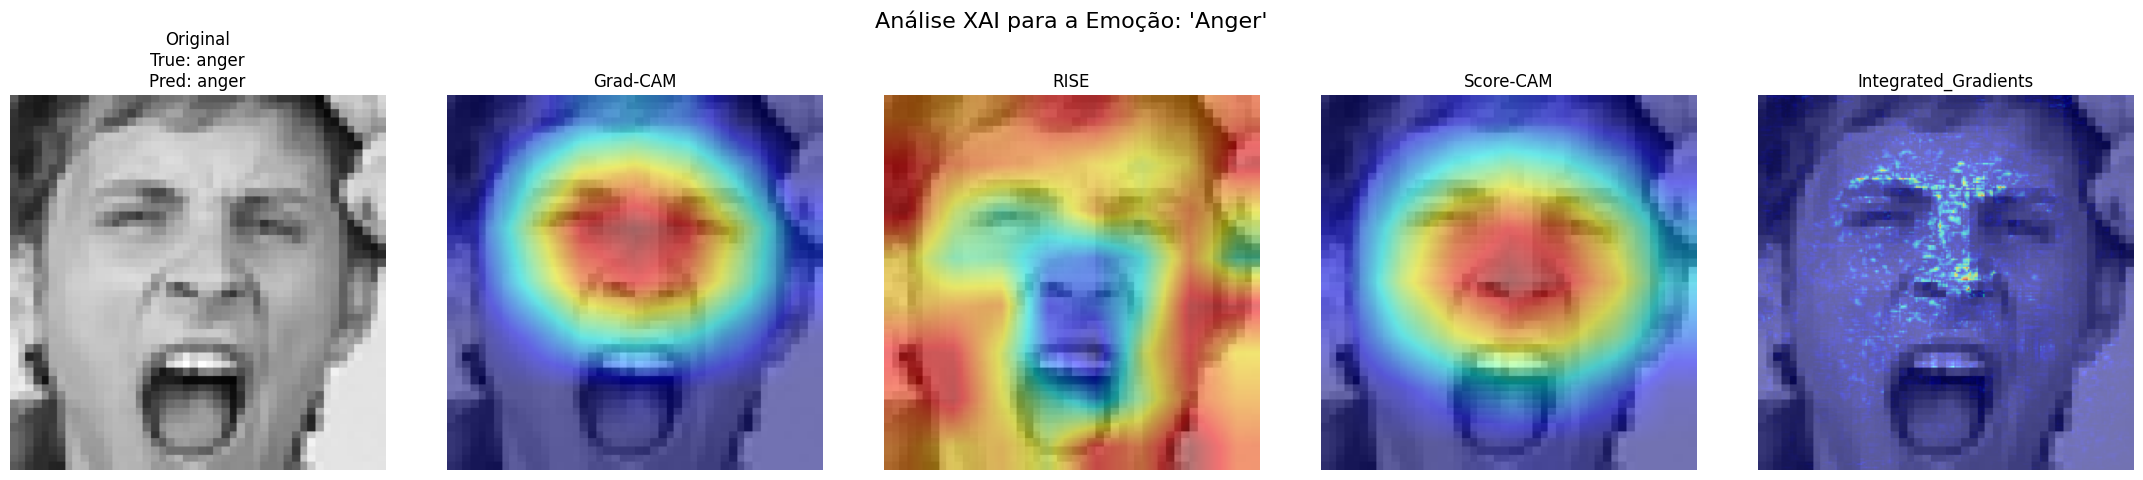


Processando e salvando o exemplo para a emoção: 'contempt'...
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'


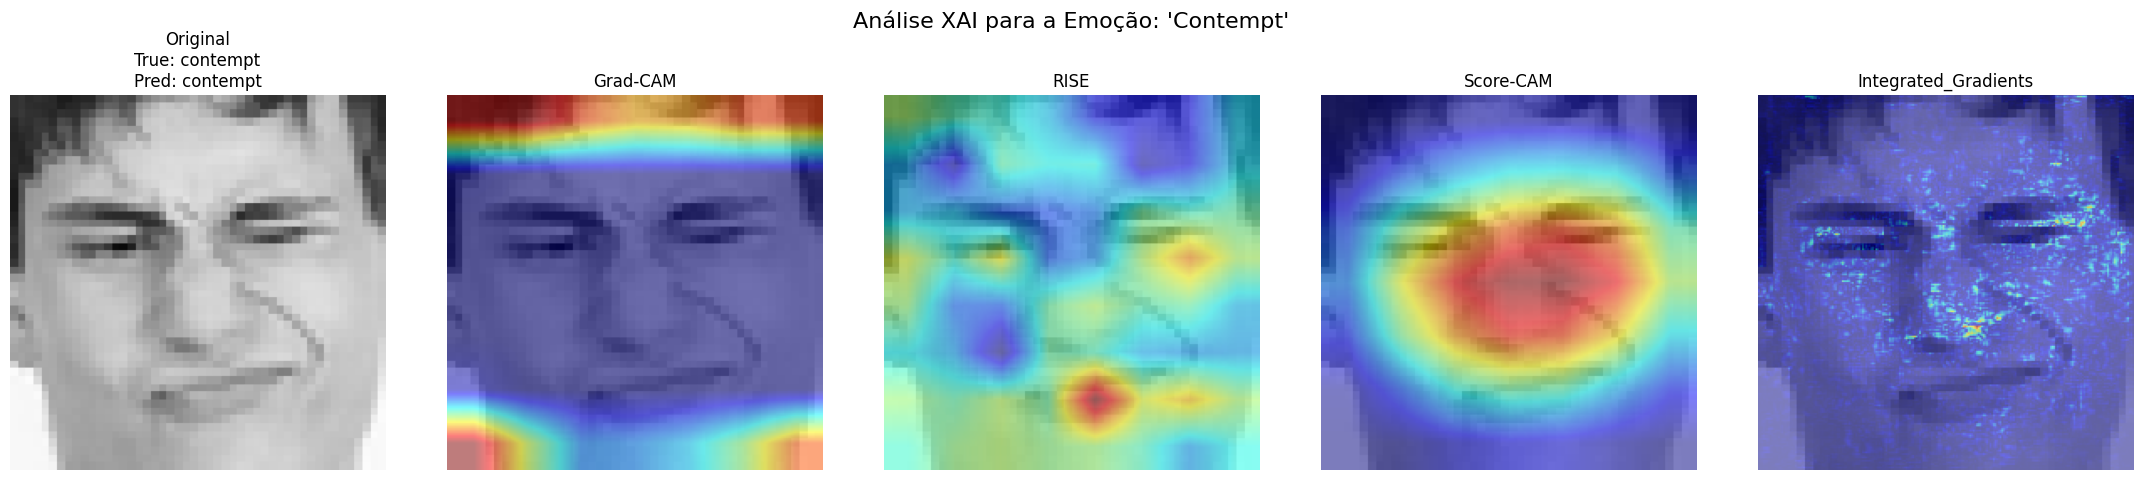


Processando e salvando o exemplo para a emoção: 'disgust'...
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'


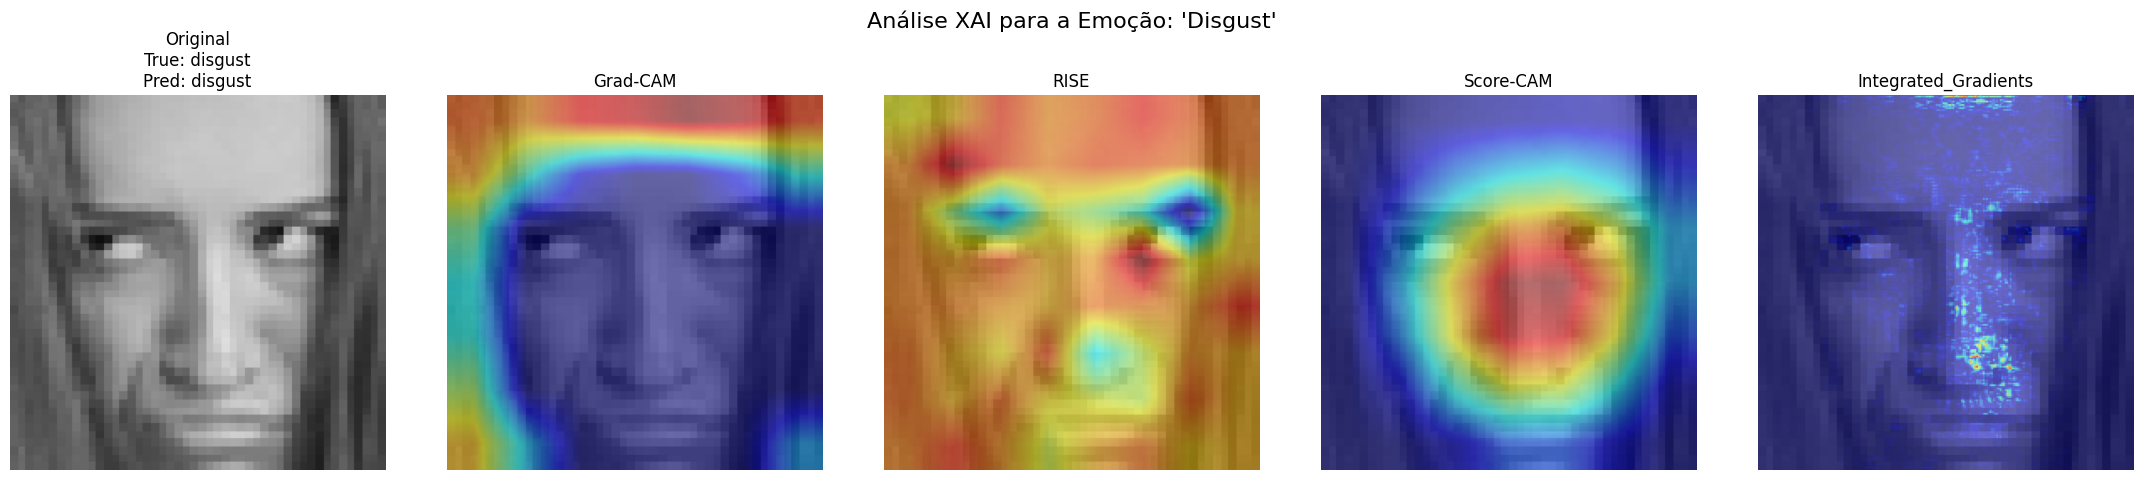


Processando e salvando o exemplo para a emoção: 'fear'...
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'


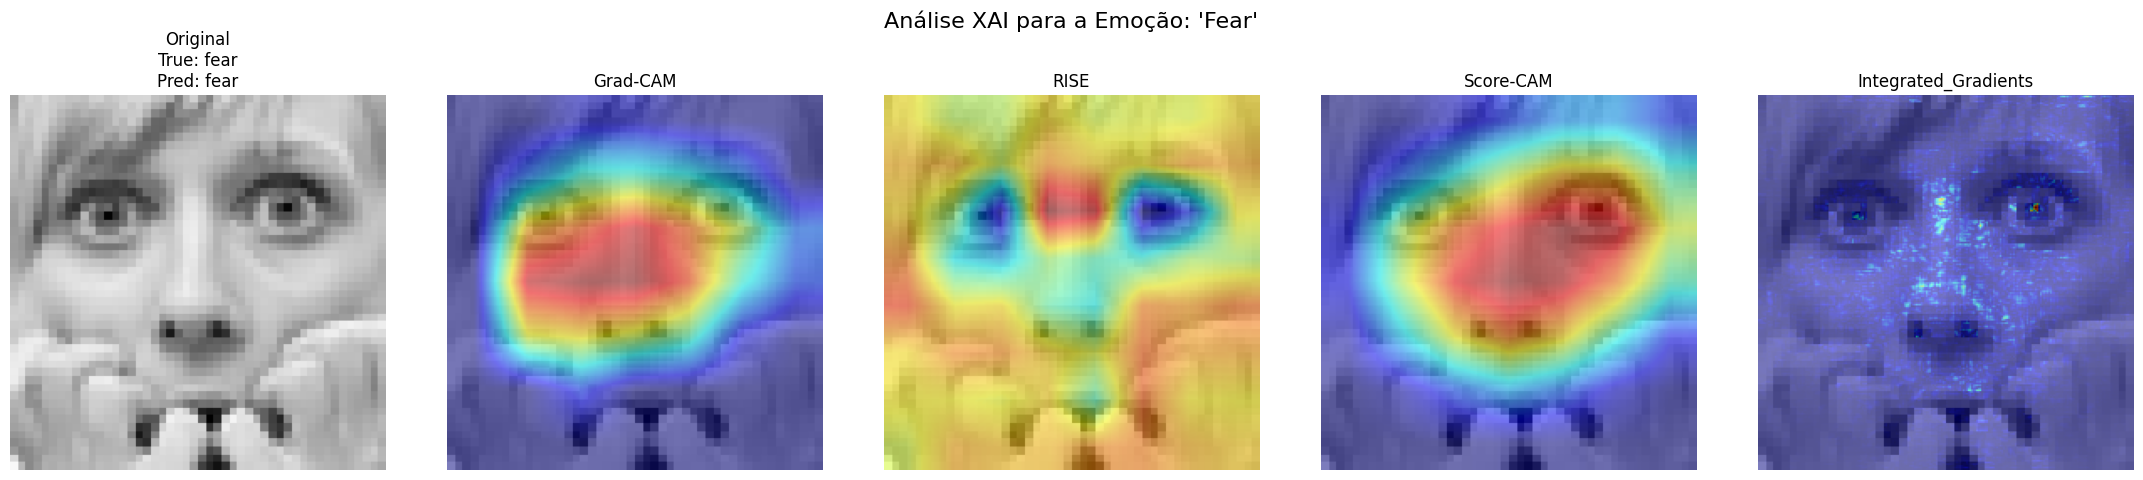


Processando e salvando o exemplo para a emoção: 'happiness'...
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'


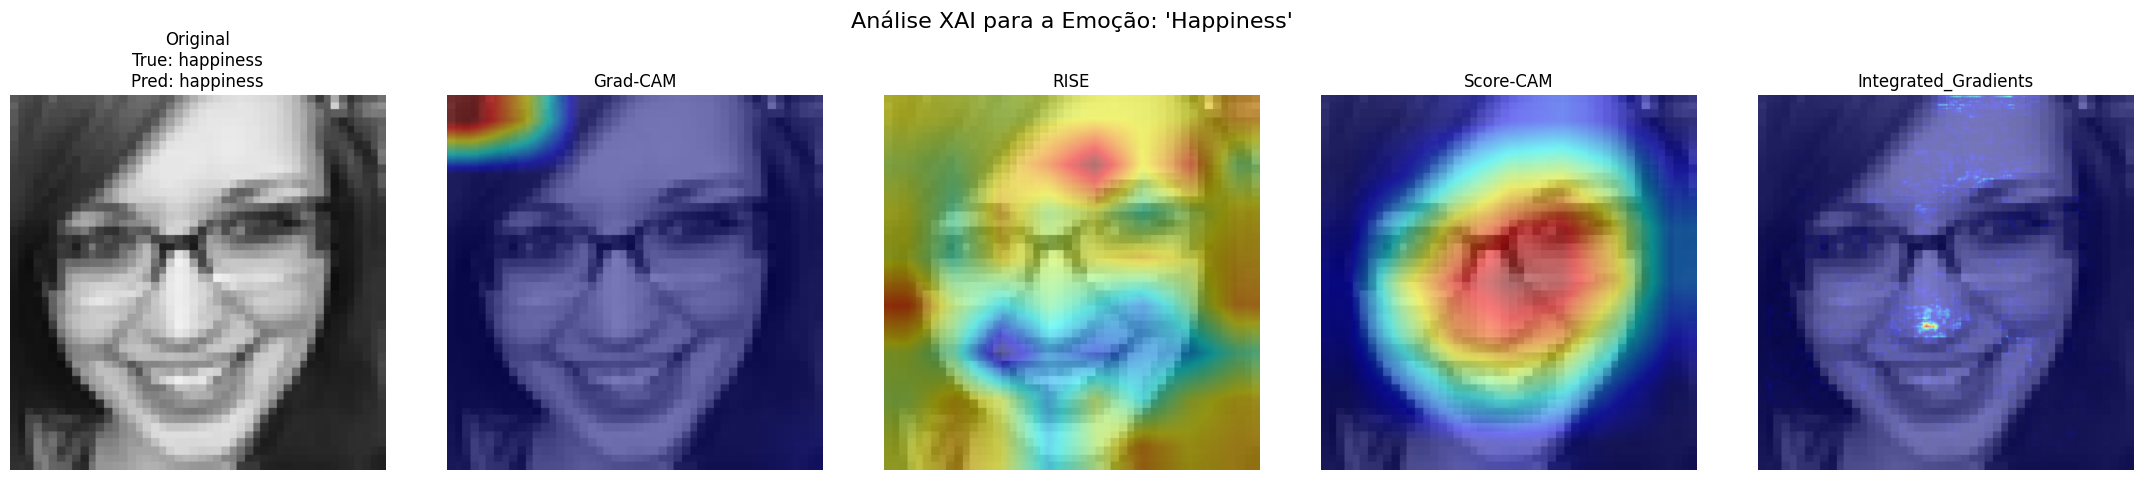


Processando e salvando o exemplo para a emoção: 'neutral'...
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'


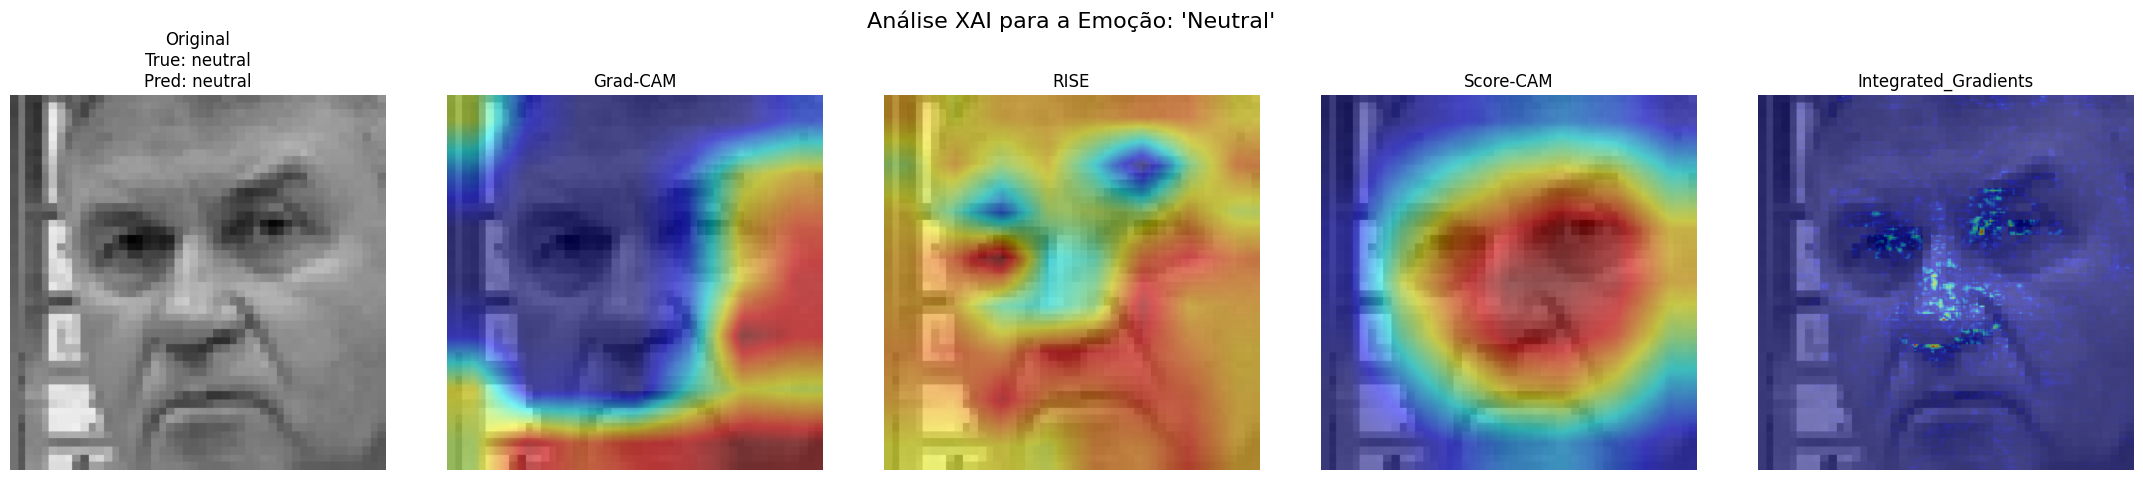


Processando e salvando o exemplo para a emoção: 'sadness'...
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'


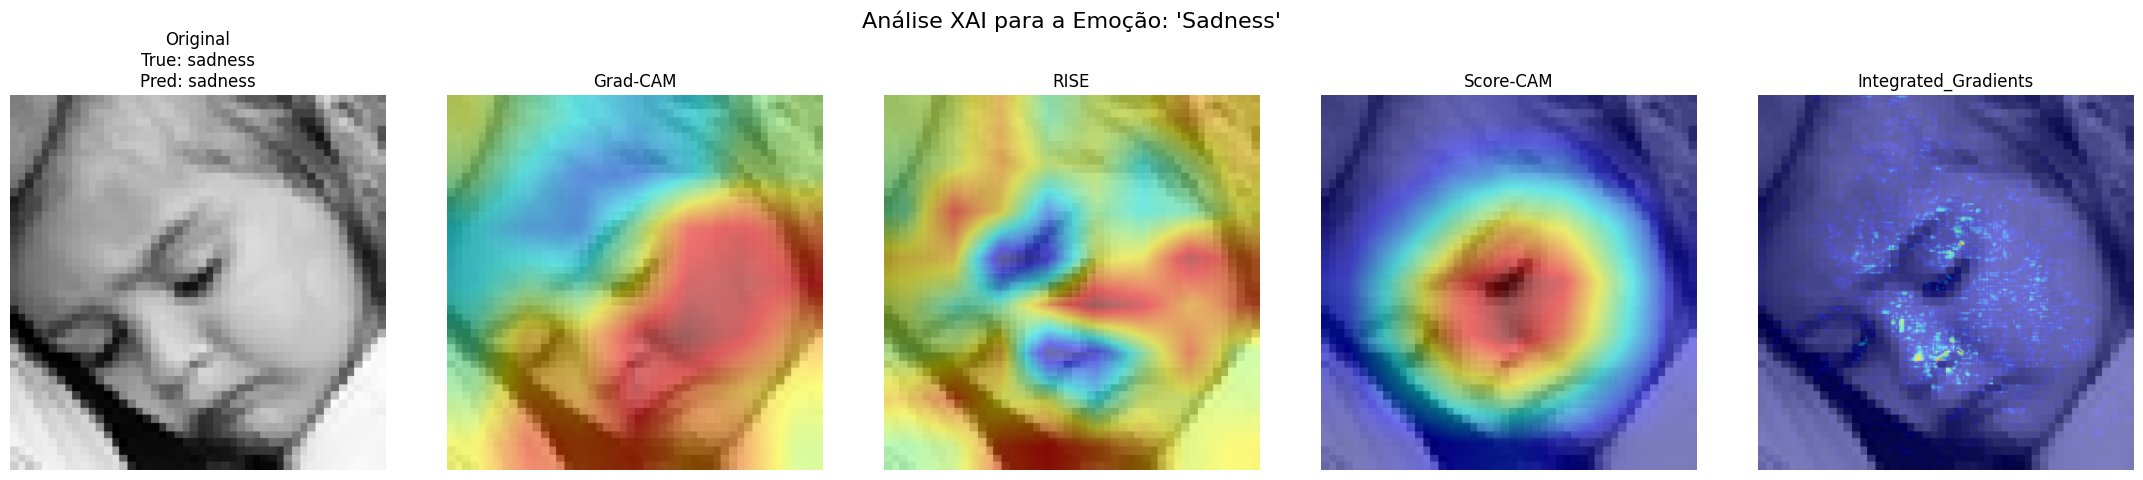


Processando e salvando o exemplo para a emoção: 'surprise'...
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'


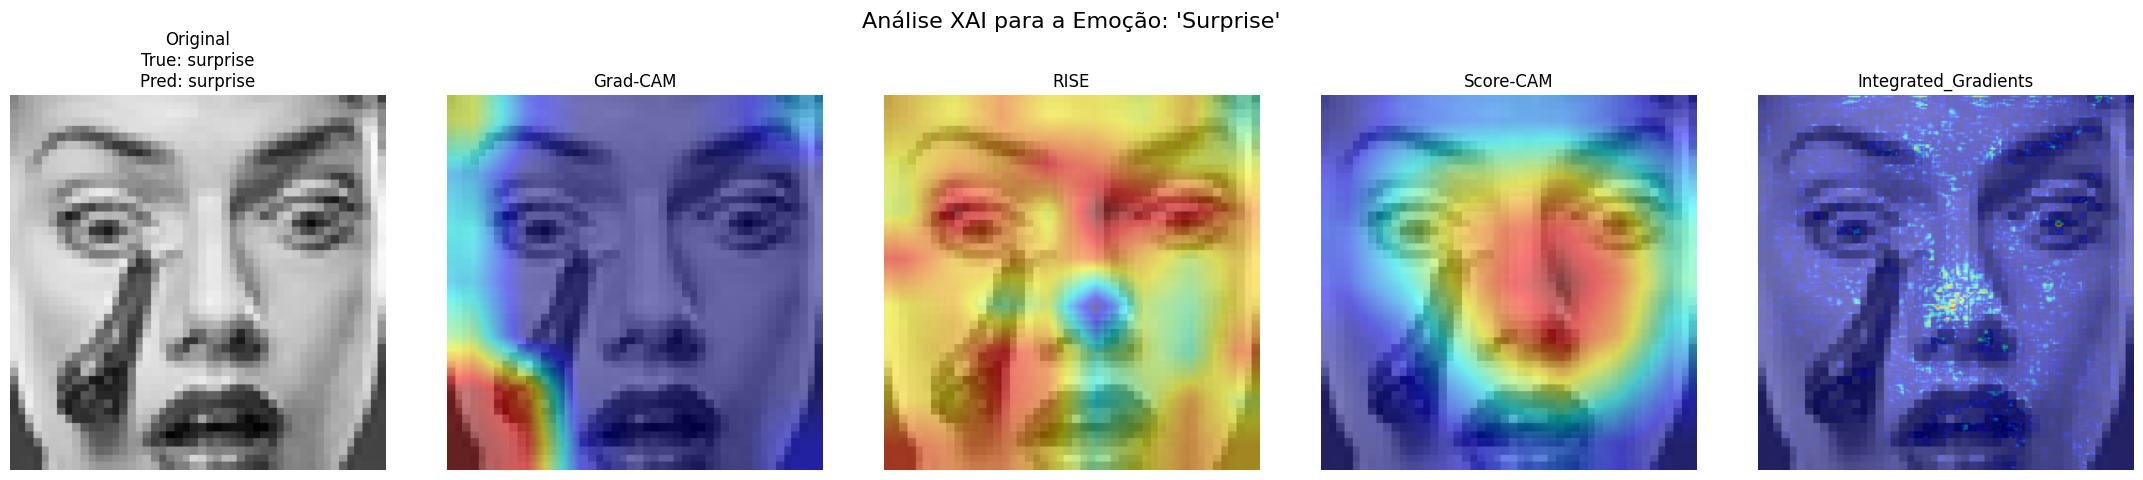



Processo finalizado com sucesso!
Todos os gráficos de exemplo foram salvos em '/kaggle/working/xai_results/Resumo_Por_Emocao'.


In [ ]:
print("\n--- Gerando e Salvando um Exemplo de Sucesso para Cada Emoção ---")

summary_output_dir = os.path.join(BASE_OUTPUT_DIR, "Resumo_Por_Emocao")
os.makedirs(summary_output_dir, exist_ok=True)
print(f"Os gráficos de resumo serão salvos em: {summary_output_dir}")

examples_to_save = {}
for emotion_idx, emotion_name in enumerate(class_names_xai):
    for case_info in sucessos:
        if case_info['true_label_idx'] == emotion_idx:
            examples_to_save[emotion_name] = case_info
            break

print(f"\nEncontrados exemplos de sucesso para as seguintes emoções: {list(examples_to_save.keys())}")

for emotion_name, case_info in examples_to_save.items():
    print(f"\nProcessando e salvando o exemplo para a emoção: '{emotion_name}'...")
    
    img_path = case_info['filepath']
    img_array = load_and_preprocess_single_image(img_path)
    pred_idx = case_info['pred_label_idx']
    true_idx = case_info['true_label_idx']
    true_label_name = class_names_xai[true_idx]
    pred_label_name = class_names_xai[pred_idx]
    
    fig, axes = plt.subplots(1, len(xai_methods) + 1, figsize=(22, 5))
    
    original_img_display = deprocess_input_vggface(img_array)
    axes[0].imshow(original_img_display, cmap='gray')
    axes[0].set_title(f"Original\nTrue: {true_label_name}\nPred: {pred_label_name}")
    axes[0].axis('off')
    
    for i, (method_name, method_func) in enumerate(xai_methods.items()):
        if method_name in ["Grad-CAM", "Score-CAM"]:
            heatmap = method_func(model, img_array, LAST_CONV_LAYER_NAME, class_index=pred_idx)
        else:
            heatmap = method_func(model, img_array, class_index=pred_idx)
            
        superimposed_img = superimpose_heatmap(original_img_display / 255.0, heatmap)
        
        axes[i+1].imshow(superimposed_img)
        axes[i+1].set_title(method_name)
        axes[i+1].axis('off')

    fig.suptitle(f"Análise XAI para a Emoção: '{emotion_name.capitalize()}'", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    image_id = os.path.splitext(os.path.basename(img_path))[0]
    save_filename = f"True-{true_label_name}_Pred-{pred_label_name}_{image_id}.png"
    save_path = os.path.join(summary_output_dir, save_filename)
    
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    plt.close(fig)

print("\n\nProcesso finalizado com sucesso!")
print(f"Todos os gráficos de exemplo foram salvos em '{summary_output_dir}'.")

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

print("\n--- Analisando a Performance do Modelo em Cada Emoção ---")

y_true = [item['true_label_idx'] for item in analysis_data]
y_pred = [item['pred_label_idx'] for item in analysis_data]
class_names = class_names_xai

report_dict = classification_report(y_true, y_pred, target_names=class_names, zero_division=0, output_dict=True)

class_metrics = {name: metrics for name, metrics in report_dict.items() if name in class_names}
performance_df = pd.DataFrame(class_metrics).T
performance_df = performance_df.rename(columns={'precision': 'Precisão', 'recall': 'Recall', 'f1-score': 'F1-Score', 'support': 'Nº Amostras'})

print("\nTabela de Performance do Modelo por Emoção (ordenada por F1-Score):")
sorted_performance = performance_df.sort_values(by='F1-Score', ascending=False)
print(sorted_performance)

print("\n--- Conclusão da Análise de Performance ---")
best_class = sorted_performance.index[0]
best_f1_score = sorted_performance['F1-Score'][0]

worst_class = sorted_performance.index[-1]
worst_f1_score = sorted_performance['F1-Score'][-1]

print(f"A classe com a performance mais robusta é '{best_class}' (F1-Score: {best_f1_score:.2f}).")
print(f"A classe com a performance mais fraca é '{worst_class}' (F1-Score: {worst_f1_score:.2f}).")
print("\n'Anger' foi uma escolha razoável para a análise inicial, pois geralmente está entre as classes com melhor desempenho.")
print("No entanto, para uma análise completa, o ideal seria comparar os resultados quantitativos da XAI (Fidelidade, Robustez, etc.)")
print(f"entre a melhor classe ('{best_class}') e a pior classe ('{worst_class}') para entender como a performance do modelo afeta a qualidade da explicação.")


--- Analisando a Performance do Modelo em Cada Emoção ---

Tabela de Performance do Modelo por Emoção (ordenada por F1-Score):
           Precisão    Recall  F1-Score  Nº Amostras
happiness  0.826855  0.896552  0.860294       1827.0
neutral    0.814346  0.743165  0.777129       2597.0
surprise   0.770810  0.751111  0.760833        900.0
anger      0.720379  0.708075  0.714174        644.0
sadness    0.561565  0.570093  0.565797        856.0
disgust    0.444444  0.561404  0.496124         57.0
fear       0.397683  0.616766  0.483568        167.0
contempt   0.447368  0.333333  0.382022         51.0

--- Conclusão da Análise de Performance ---
A classe com a performance mais robusta é 'happiness' (F1-Score: 0.86).
A classe com a performance mais fraca é 'contempt' (F1-Score: 0.38).

'Anger' foi uma escolha razoável para a análise inicial, pois geralmente está entre as classes com melhor desempenho.
No entanto, para uma análise completa, o ideal seria comparar os resultados quantitativos 

/tmp/ipykernel_39/3298431443.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  best_f1_score = sorted_performance['F1-Score'][0]
/tmp/ipykernel_39/3298431443.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  worst_f1_score = sorted_performance['F1-Score'][-1]



--- Iniciando Avaliação de Fidelidade para as Classes de Melhor Performance ---

Analisando as 4 melhores classes: ['happiness', 'neutral', 'surprise', 'anger']

===== Executando Teste de Fidelidade para a Classe: 'happiness' =====

===== Executando Teste de Fidelidade para a Classe: 'neutral' =====

===== Executando Teste de Fidelidade para a Classe: 'surprise' =====
  - Executando teste para: Grad-CAM
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'
  - Executando teste para: RISE
  - Executando teste para: Score-CAM
  - Executando teste para: Integrated_Gradients
Gráfico de fidelidade para 'surprise' salvo com sucesso em: /kaggle/working/xai_results/Graficos_de_Avaliacao/Delecao/Deletion_Test_Fidelity_surprise.png


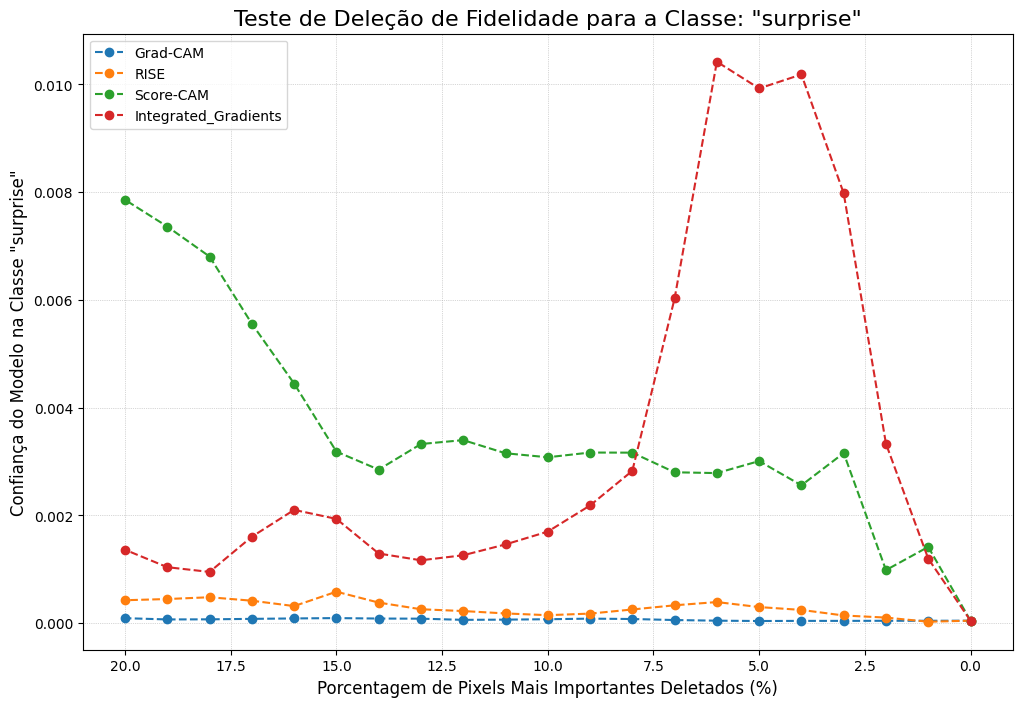


===== Executando Teste de Fidelidade para a Classe: 'anger' =====
  - Executando teste para: Grad-CAM
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'
  - Executando teste para: RISE
  - Executando teste para: Score-CAM
  - Executando teste para: Integrated_Gradients
Gráfico de fidelidade para 'anger' salvo com sucesso em: /kaggle/working/xai_results/Graficos_de_Avaliacao/Delecao/Deletion_Test_Fidelity_anger.png


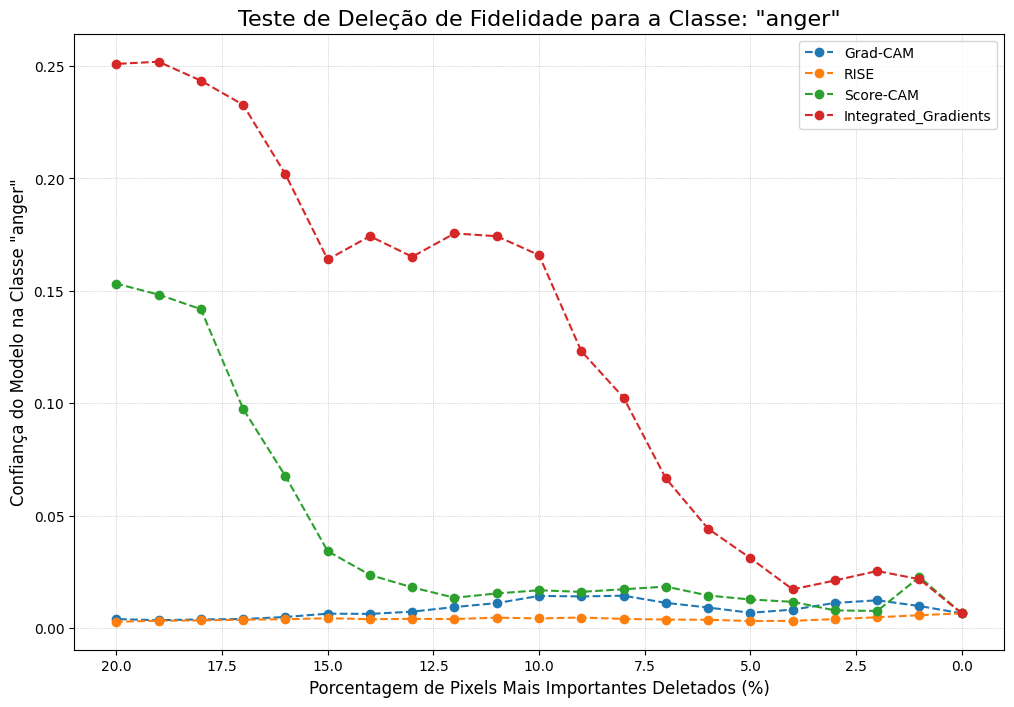



Análise de fidelidade para as melhores classes concluída.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import tensorflow as tf

print("\n--- Iniciando Avaliação de Fidelidade para as Classes de Melhor Performance ---")

def run_deletion_test(model, img_array_preprocessed, heatmap, class_index, steps=20, pixels_per_step_percent=1):
    """Executa o teste de deleção para avaliar a fidelidade de um heatmap."""
    img_display = deprocess_input_vggface(img_array_preprocessed)
    heatmap_resized = cv2.resize(heatmap, (img_display.shape[1], img_display.shape[0]))
    total_pixels = img_display.shape[0] * img_display.shape[1]
    flat_heatmap_indices = np.argsort(heatmap_resized.flatten())[::-1]
    num_pixels_per_st1ep = int((total_pixels * pixels_per_step_percent) / 100)
    scores = []
    
    initial_logits = model.predict(img_array_preprocessed, verbose=0)
    initial_probs = tf.nn.softmax(initial_logits).numpy()
    initial_score = initial_probs[0][class_index]
    scores.append(initial_score)
    
    img_deleted = img_display.copy()
    
    for i in range(steps):
        start_index = i * num_pixels_per_step
        end_index = start_index + num_pixels_per_step
        pixel_indices_to_delete = flat_heatmap_indices[start_index:end_index]
        rows, cols = np.unravel_index(pixel_indices_to_delete, heatmap_resized.shape)
        img_deleted[rows, cols] = 0
        img_deleted_preprocessed = preprocess_input_vggface(np.expand_dims(img_deleted, axis=0))
        logits = model.predict(img_deleted_preprocessed, verbose=0)
        probs = tf.nn.softmax(logits).numpy()
        score = probs[0][class_index]
        scores.append(score)
        
    percentages = [0] + [pixels_per_step_percent * (i + 1) for i in range(steps)]
    return percentages, scores

N_TOP_CLASSES = 4
top_classes_to_analyze = sorted_performance.index[:N_TOP_CLASSES].tolist()

print(f"\nAnalisando as {N_TOP_CLASSES} melhores classes: {top_classes_to_analyze}")

for class_name in top_classes_to_analyze:
    print(f"\n===== Executando Teste de Fidelidade para a Classe: '{class_name}' =====")
    
    class_idx_to_find = class_names_xai.index(class_name)
    example_case = None
    for case in sucessos:
        if case['true_label_idx'] == class_idx_to_find:
            example_case = case
            break
            
    if not example_case:
        print(f"AVISO: Nenhum caso de sucesso encontrado para '{class_name}'. Pulando.")
        continue
        
    img_array = load_and_preprocess_single_image(example_case['filepath'])
    class_idx = example_case['true_label_idx']
    
    analysis_results = {}
    for method_name, method_func in xai_methods.items():
        print(f"  - Executando teste para: {method_name}")
        
        if method_name in ["Grad-CAM", "Score-CAM"]:
            heatmap = method_func(model, img_array, LAST_CONV_LAYER_NAME, class_index=class_idx)
        else:
            heatmap = method_func(model, img_array, class_index=class_idx)
        
        percentages, scores = run_deletion_test(model, img_array, heatmap, class_idx)
        analysis_results[method_name] = (percentages, scores)

    fig, ax = plt.subplots(figsize=(12, 8))
    for method_name, (percentages, scores) in analysis_results.items():
        ax.plot(percentages, scores, marker='o', linestyle='--', label=method_name)

    ax.set_title(f'Teste de Deleção de Fidelidade para a Classe: "{class_name}"', fontsize=16)
    ax.set_xlabel('Porcentagem de Pixels Mais Importantes Deletados (%)', fontsize=12)
    ax.set_ylabel(f'Confiança do Modelo na Classe "{class_name}"', fontsize=12)
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)
    ax.legend(fontsize=10)
    ax.invert_xaxis()

    save_dir = os.path.join(BASE_OUTPUT_DIR, "Graficos_de_Avaliacao/Delecao")
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"Deletion_Test_Fidelity_{class_name}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    print(f"Gráfico de fidelidade para '{class_name}' salvo com sucesso em: {save_path}")
    plt.show()
    plt.close(fig)

print("\n\nAnálise de fidelidade para as melhores classes concluída.")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from scipy.stats import pearsonr

print("\n--- Iniciando Avaliação de Robustez OTIMIZADA para as Classes de Melhor Performance ---")

def deprocess_input_vggface(x):
    x_temp = x.copy()
    if len(x_temp.shape) == 4 and x_temp.shape[0] == 1:
        x_temp = x_temp[0, ...]
    x_temp[..., 0] += 91.4953
    x_temp[..., 1] += 103.8827
    x_temp[..., 2] += 131.0912
    x_temp = x_temp[..., ::-1] # BGR -> RGB
    x_temp = np.clip(x_temp, 0, 255).astype('uint8')
    return x_temp

def add_gaussian_noise(image_uint8, strength=20.0):
    img_float = image_uint8.astype(np.float32)
    noise = np.random.normal(0, strength, img_float.shape)
    noisy_img = np.clip(img_float + noise, 0, 255)
    return noisy_img.astype(np.uint8)

def calculate_heatmap_similarity(heatmap1, heatmap2):
    h1_flat = heatmap1.flatten()
    h2_flat = heatmap2.flatten()
    if np.std(h1_flat) < 1e-6 or np.std(h2_flat) < 1e-6:
        return 1.0 if np.allclose(h1_flat, h2_flat) else 0.0
    correlation, _ = pearsonr(h1_flat, h2_flat)
    return correlation

def get_integrated_gradients_fast(model, img_array, class_index, m_steps=10):
    baseline = tf.zeros_like(img_array)
    interpolated_images = tf.concat(
        [baseline + (float(i) / m_steps) * (img_array - baseline) for i in range(m_steps + 1)],
        axis=0
    )
    with tf.GradientTape() as tape:
        tape.watch(interpolated_images)
        logits = model(interpolated_images, training=False)
        predictions = tf.cast(logits, tf.float32) 
        top_class_predictions = predictions[:, class_index]
    grads = tape.gradient(top_class_predictions, interpolated_images)
    if grads is None: return np.array([])
    avg_grads = tf.reduce_mean(grads, axis=0)
    integrated_gradients = (img_array - baseline) * avg_grads
    heatmap = tf.reduce_sum(tf.math.abs(integrated_gradients), axis=-1)
    heatmap_np = np.squeeze(heatmap.numpy())
    min_val, max_val = np.min(heatmap_np), np.max(heatmap_np)
    if max_val - min_val < 1e-7: return np.zeros_like(heatmap_np)
    heatmap_np = (heatmap_np - min_val) / (max_val - min_val)
    return heatmap_np

xai_methods_fast = {
    "Grad-CAM": get_gradcam,
    "RISE": get_rise,
    "Score-CAM": get_score_cam,
    "Integrated_Gradients": get_integrated_gradients_fast,
}

N_TOP_CLASSES = 4
top_classes_to_analyze = sorted_performance.index[:N_TOP_CLASSES].tolist()

print(f"\nAnalisando a robustez para as {N_TOP_CLASSES} melhores classes...")


--- Iniciando Avaliação de Robustez OTIMIZADA para as Classes de Melhor Performance ---

Analisando a robustez para as 4 melhores classes...



===== Executando Teste de Robustez OTIMIZADO para a Classe: 'happiness' =====

===== Executando Teste de Robustez OTIMIZADO para a Classe: 'neutral' =====

===== Executando Teste de Robustez OTIMIZADO para a Classe: 'surprise' =====

===== Executando Teste de Robustez OTIMIZADO para a Classe: 'anger' =====
  - Avaliando robustez para: Grad-CAM
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definid

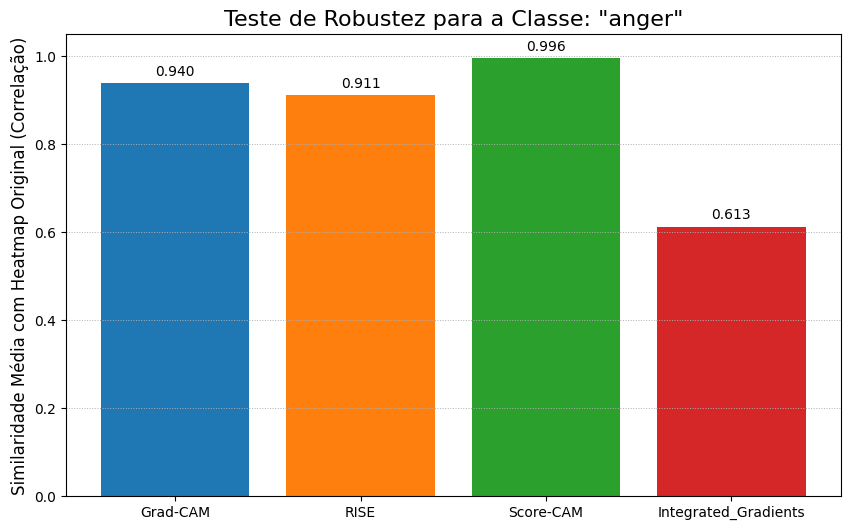



Análise de robustez OTIMIZADA para as melhores classes concluída.


In [ ]:
for class_name in top_classes_to_analyze:
    print(f"\n===== Executando Teste de Robustez OTIMIZADO para a Classe: '{class_name}' =====")
    
    class_idx_to_find = class_names_xai.index(class_name)
    example_case = next((case for case in sucessos if case['true_label_idx'] == class_idx_to_find), None)
            
    if not example_case:
        print(f"AVISO: Nenhum caso de sucesso encontrado para '{class_name}'. Pulando.")
        continue
        
    img_array = load_and_preprocess_single_image(example_case['filepath'])
    class_idx = example_case['true_label_idx']
    
    N_PERTURBATIONS = 5 
    robustness_scores = {}

    for method_name, method_func in xai_methods_fast.items():
        print(f"  - Avaliando robustez para: {method_name}")
        
        if method_name in ["Grad-CAM", "Score-CAM"]:
            original_heatmap = method_func(model, img_array, LAST_CONV_LAYER_NAME, class_index=class_idx)
        else:
            original_heatmap = method_func(model, img_array, class_index=class_idx)
        
        similarities = []
        for _ in range(N_PERTURBATIONS):
            noisy_img_display = add_gaussian_noise(deprocess_input_vggface(img_array))
            noisy_img_preprocessed = preprocess_input_vggface(np.expand_dims(noisy_img_display, axis=0))
            if method_name in ["Grad-CAM", "Score-CAM"]:
                noisy_heatmap = method_func(model, noisy_img_preprocessed, LAST_CONV_LAYER_NAME, class_index=class_idx)
            else:
                noisy_heatmap = method_func(model, noisy_img_preprocessed, class_index=class_idx)
            similarities.append(calculate_heatmap_similarity(original_heatmap, noisy_heatmap))
            
        robustness_scores[method_name] = np.mean(similarities)
    
    plt.figure(figsize=(10, 6))
    methods = list(robustness_scores.keys())
    scores = list(robustness_scores.values())
    bars = plt.bar(methods, scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    plt.title(f'Teste de Robustez para a Classe: "{class_name}"', fontsize=16)
    plt.ylabel('Similaridade Média com Heatmap Original (Correlação)', fontsize=12)
    plt.ylim(0, 1.05)
    plt.grid(axis='y', linestyle=':', linewidth=0.7)
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom')
    save_dir = os.path.join(BASE_OUTPUT_DIR, "Graficos_de_Avaliacao")
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"Robustness_Test_{class_name}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Gráfico de robustez para '{class_name}' salvo com sucesso em: {save_path}")
    plt.show()
    plt.close()

print("\n\nAnálise de robustez OTIMIZADA para as melhores classes concluída.")


--- Definindo Funções para o Teste de Esparsidade e Coerência ---

Analisando Esparsidade e Coerência para as 4 melhores classes: ['happiness', 'neutral', 'surprise', 'anger']

===== Executando Análise para a Classe: 'happiness' =====
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'


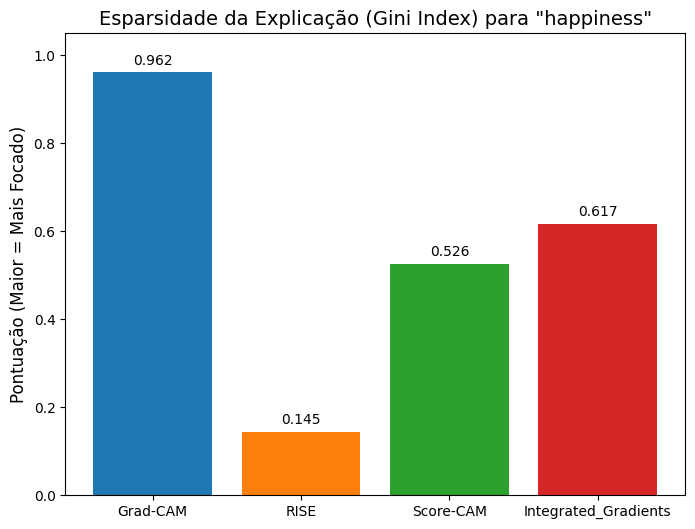

Gráfico de esparsidade para 'happiness' salvo em: /kaggle/working/xai_results/Graficos_de_Avaliacao/Sparsity_Test_happiness.png


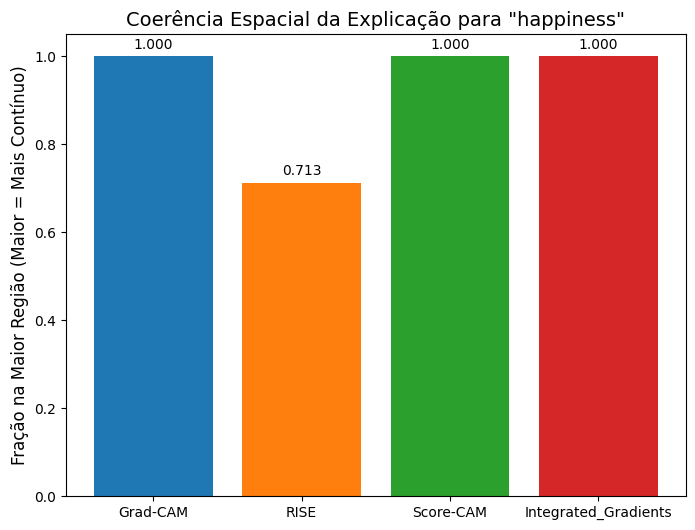

Gráfico de coerência para 'happiness' salvo em: /kaggle/working/xai_results/Graficos_de_Avaliacao/Coherence_Test_happiness.png

===== Executando Análise para a Classe: 'neutral' =====
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'


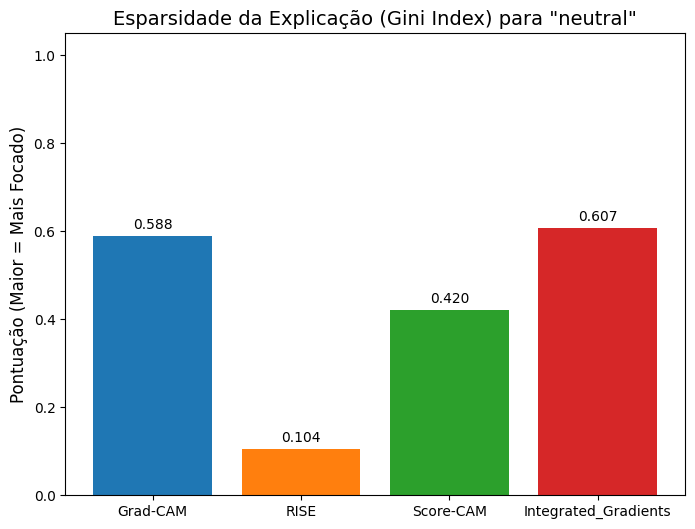

Gráfico de esparsidade para 'neutral' salvo em: /kaggle/working/xai_results/Graficos_de_Avaliacao/Sparsity_Test_neutral.png


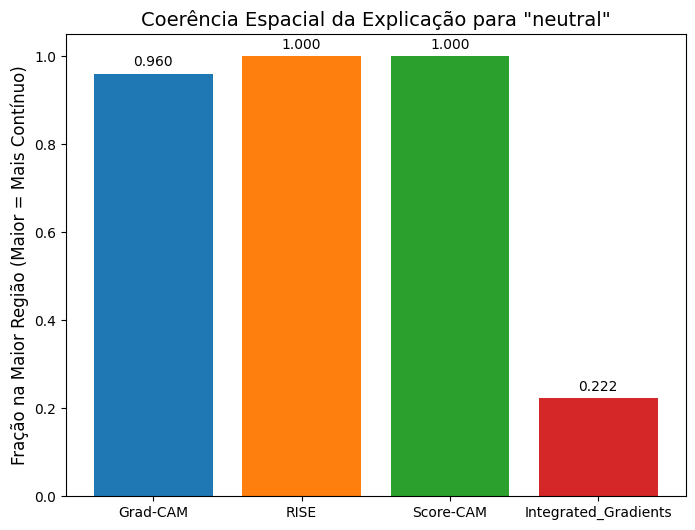

Gráfico de coerência para 'neutral' salvo em: /kaggle/working/xai_results/Graficos_de_Avaliacao/Coherence_Test_neutral.png

===== Executando Análise para a Classe: 'surprise' =====
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'


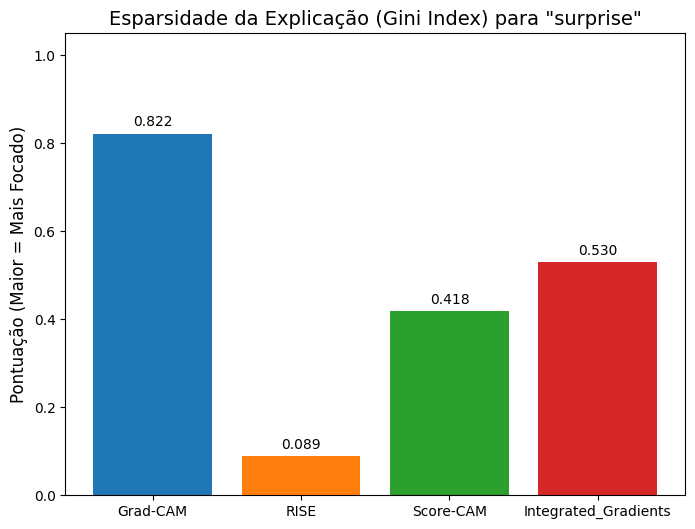

Gráfico de esparsidade para 'surprise' salvo em: /kaggle/working/xai_results/Graficos_de_Avaliacao/Sparsity_Test_surprise.png


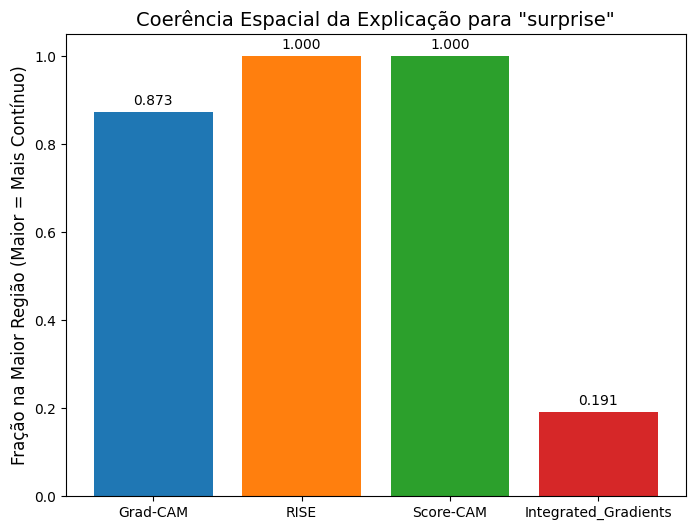

Gráfico de coerência para 'surprise' salvo em: /kaggle/working/xai_results/Graficos_de_Avaliacao/Coherence_Test_surprise.png

===== Executando Análise para a Classe: 'anger' =====
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'


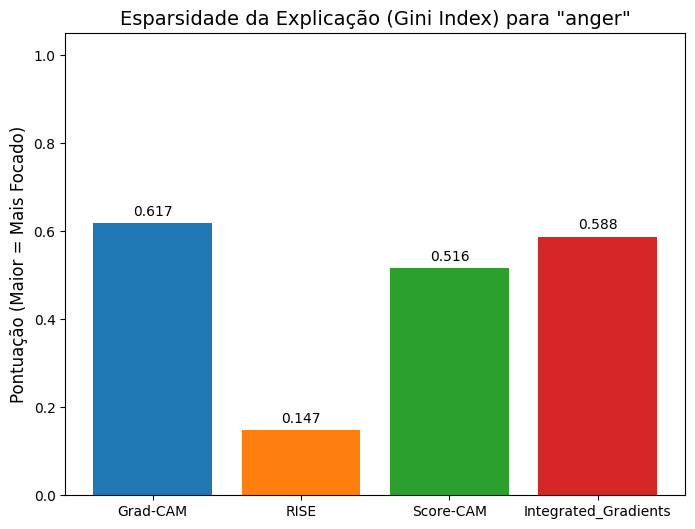

Gráfico de esparsidade para 'anger' salvo em: /kaggle/working/xai_results/Graficos_de_Avaliacao/Sparsity_Test_anger.png


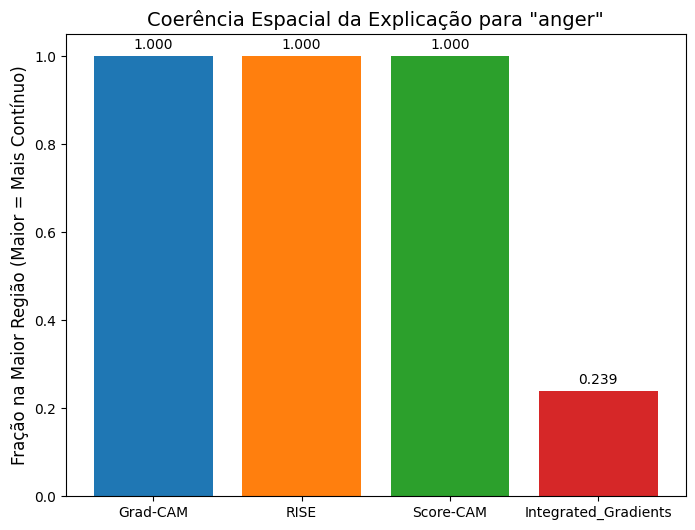

Gráfico de coerência para 'anger' salvo em: /kaggle/working/xai_results/Graficos_de_Avaliacao/Coherence_Test_anger.png


Análise de esparsidade e coerência para as melhores classes concluída.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.measure import label


print("\n--- Definindo Funções para o Teste de Esparsidade e Coerência ---")

def calculate_gini_index(heatmap):
    h_flat = np.abs(heatmap.flatten())
    h_sorted = np.sort(h_flat)
    n = len(h_sorted)
    if n == 0 or np.sum(h_sorted) == 0: return 0.0
    cum_sum = np.cumsum(h_sorted)
    B = np.sum(cum_sum) / cum_sum[-1]
    gini = (n + 1 - 2 * B) / n
    return gini

def calculate_spatial_coherence(heatmap, threshold_percent=0.5):
    if np.max(heatmap) - np.min(heatmap) < 1e-7: return 1.0
    h_norm = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap) + 1e-7)
    threshold = threshold_percent * np.max(h_norm)
    binary_map = h_norm > threshold
    labeled_map, num_labels = label(binary_map, connectivity=2, background=0, return_num=True)
    if num_labels == 0: return 0.0
    total_energy = np.sum(h_norm[binary_map])
    if total_energy == 0: return 0.0
    max_cluster_energy = 0
    for i in range(1, num_labels + 1):
        cluster_mask = labeled_map == i
        cluster_energy = np.sum(h_norm[cluster_mask])
        if cluster_energy > max_cluster_energy:
            max_cluster_energy = cluster_energy
    return max_cluster_energy / total_energy

N_TOP_CLASSES = 4
top_classes_to_analyze = sorted_performance.index[:N_TOP_CLASSES].tolist()

print(f"\nAnalisando Esparsidade e Coerência para as {N_TOP_CLASSES} melhores classes: {top_classes_to_analyze}")

for class_name in top_classes_to_analyze:
    print(f"\n===== Executando Análise para a Classe: '{class_name}' =====")
    
    class_idx_to_find = class_names_xai.index(class_name)
    example_case = next((case for case in sucessos if case['true_label_idx'] == class_idx_to_find), None)
            
    if not example_case:
        print(f"AVISO: Nenhum caso de sucesso encontrado para '{class_name}'. Pulando.")
        continue
        
    img_array = load_and_preprocess_single_image(example_case['filepath'])
    class_idx = example_case['true_label_idx']
    
    sparsity_scores = {}
    coherence_scores = {}

    for method_name, method_func in xai_methods.items():
        if method_name in ["Grad-CAM", "Score-CAM"]:
            heatmap = method_func(model, img_array, LAST_CONV_LAYER_NAME, class_index=class_idx)
        else:
            heatmap = method_func(model, img_array, class_index=class_idx)
        
        sparsity_scores[method_name] = calculate_gini_index(heatmap)
        coherence_scores[method_name] = calculate_spatial_coherence(heatmap)
    
    plt.figure(figsize=(8, 6))
    methods = list(sparsity_scores.keys())
    scores = list(sparsity_scores.values())
    bars = plt.bar(methods, scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    plt.title(f'Esparsidade da Explicação (Gini Index) para "{class_name}"', fontsize=14)
    plt.ylabel('Pontuação (Maior = Mais Focado)', fontsize=12)
    plt.ylim(0, 1.05)
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom')
    
    save_dir = os.path.join(BASE_OUTPUT_DIR, "Graficos_de_Avaliacao")
    os.makedirs(save_dir, exist_ok=True)
    save_path_sparsity = os.path.join(save_dir, f"Sparsity_Test_{class_name}.png")
    plt.savefig(save_path_sparsity, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Gráfico de esparsidade para '{class_name}' salvo em: {save_path_sparsity}")

    plt.figure(figsize=(8, 6))
    methods = list(coherence_scores.keys())
    scores = list(coherence_scores.values())
    bars = plt.bar(methods, scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    plt.title(f'Coerência Espacial da Explicação para "{class_name}"', fontsize=14)
    plt.ylabel('Fração na Maior Região (Maior = Mais Contínuo)', fontsize=12)
    plt.ylim(0, 1.05)
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom')
        
    save_path_coherence = os.path.join(save_dir, f"Coherence_Test_{class_name}.png")
    plt.savefig(save_path_coherence, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Gráfico de coerência para '{class_name}' salvo em: {save_path_coherence}")

print("\n\nAnálise de esparsidade e coerência para as melhores classes concluída.")

In [ ]:
print("\n--- Iniciando Análise Comparativa XAI entre a Melhor e a Pior Classe ---")

def run_deletion_test(model, img_array_preprocessed, heatmap, class_index, steps=20, pixels_per_step_percent=1):
    """Executa o teste de deleção para avaliar a fidelidade de um heatmap."""
    img_display = deprocess_input_vggface(img_array_preprocessed)
    heatmap_resized = cv2.resize(heatmap, (img_display.shape[1], img_display.shape[0]))
    total_pixels = img_display.shape[0] * img_display.shape[1]
    flat_heatmap_indices = np.argsort(heatmap_resized.flatten())[::-1]
    num_pixels_per_step = int((total_pixels * pixels_per_step_percent) / 100)
    scores = []
    
    initial_pred = model.predict(img_array_preprocessed, verbose=0)
    initial_score = initial_pred[0][class_index]
    scores.append(initial_score)
    
    img_deleted = img_display.copy()
    
    for i in range(steps):
        start_index = i * num_pixels_per_step
        end_index = start_index + num_pixels_per_step
        if end_index > total_pixels:
            end_index = total_pixels
        pixel_indices_to_delete = flat_heatmap_indices[start_index:end_index]
        rows, cols = np.unravel_index(pixel_indices_to_delete, heatmap_resized.shape)
        img_deleted[rows, cols] = 0
        img_deleted_preprocessed = preprocess_input_vggface(np.expand_dims(img_deleted, axis=0))
        pred = model.predict(img_deleted_preprocessed, verbose=0)
        score = pred[0][class_index]
        scores.append(score)
        
    percentages = [0] + [pixels_per_step_percent * (i + 1) for i in range(steps)]
    return percentages, scores

def add_gaussian_noise(image_uint8, strength=20.0):
    img_float = image_uint8.astype(np.float32)
    noise = np.random.normal(0, strength, img_float.shape)
    noisy_img = np.clip(img_float + noise, 0, 255)
    return noisy_img.astype(np.uint8)

def calculate_heatmap_similarity(heatmap1, heatmap2):
    from scipy.stats import pearsonr
    h1_flat = heatmap1.flatten()
    h2_flat = heatmap2.flatten()
    if np.std(h1_flat) < 1e-6 or np.std(h2_flat) < 1e-6:
        return 1.0 if np.allclose(h1_flat, h2_flat) else 0.0
    correlation, _ = pearsonr(h1_flat, h2_flat)
    return correlation


--- Iniciando Análise Comparativa XAI entre a Melhor e a Pior Classe ---



===== Gerando Gráficos de Avaliação para a 'Melhor Classe: happiness' =====
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'


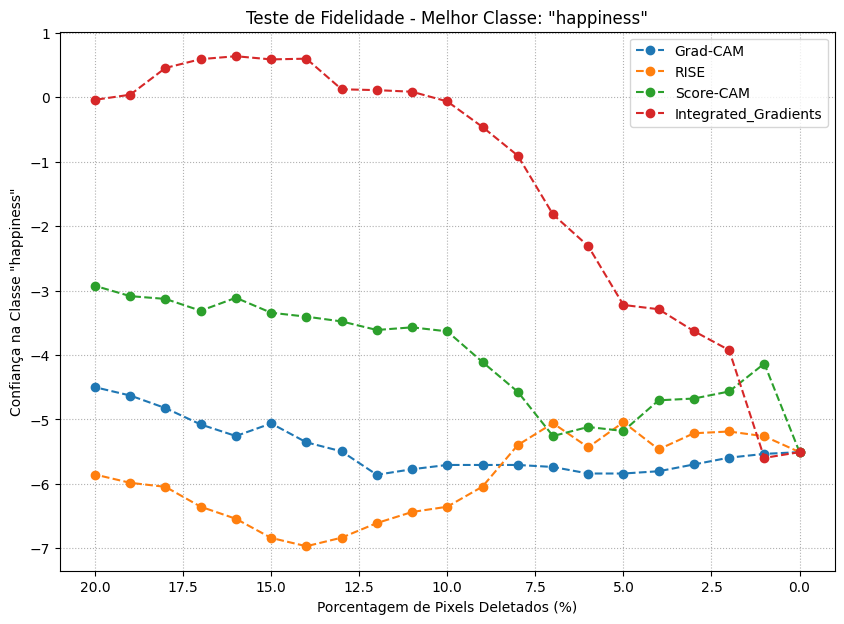

[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido com

KeyboardInterrupt: 

In [ ]:
melhor_classe_nome = sorted_performance.index[0]
pior_classe_nome = sorted_performance.index[-1]
classes_para_analise = {
    "Melhor Classe": melhor_classe_nome,
    "Pior Classe": pior_classe_nome
}

for titulo, nome_da_classe in classes_para_analise.items():
    print(f"\n===== Gerando Gráficos de Avaliação para a '{titulo}: {nome_da_classe}' =====")
    
    exemplo_encontrado = None
    indice_da_classe = class_names_xai.index(nome_da_classe)
    for case in sucessos:
        if case['true_label_idx'] == indice_da_classe:
            exemplo_encontrado = case
            break
            
    if not exemplo_encontrado:
        print(f"Não foi possível encontrar um exemplo de sucesso para '{nome_da_classe}'. Pulando.")
        continue
        
    img_array = load_and_preprocess_single_image(exemplo_encontrado['filepath'])
    class_idx = exemplo_encontrado['true_label_idx']
    
    resultados_fidelidade = {}
    for method_name, method_func in xai_methods.items():
        if method_name in ["Grad-CAM", "Score-CAM"]:
            heatmap = method_func(model, img_array, LAST_CONV_LAYER_NAME, class_index=class_idx)
        else:
            heatmap = method_func(model, img_array, class_index=class_idx)
        percentages, scores = run_deletion_test(model, img_array, heatmap, class_idx)
        resultados_fidelidade[method_name] = (percentages, scores)
        
    fig_fid, ax_fid = plt.subplots(figsize=(10, 7))
    for method_name, (percentages, scores) in resultados_fidelidade.items():
        ax_fid.plot(percentages, scores, marker='o', linestyle='--', label=method_name)
    ax_fid.set_title(f'Teste de Fidelidade - {titulo}: "{nome_da_classe}"')
    ax_fid.set_xlabel('Porcentagem de Pixels Deletados (%)')
    ax_fid.set_ylabel(f'Confiança na Classe "{nome_da_classe}"')
    ax_fid.grid(True, linestyle=':')
    ax_fid.legend()
    ax_fid.invert_xaxis()
    plt.show()
    
    resultados_robustez = {}
    for method_name, method_func in xai_methods.items():
        if method_name in ["Grad-CAM", "Score-CAM"]:
            original_heatmap = method_func(model, img_array, LAST_CONV_LAYER_NAME, class_index=class_idx)
        else:
            original_heatmap = method_func(model, img_array, class_index=class_idx)
        similarities = []
        for _ in range(10):
            noisy_img_display = add_gaussian_noise(deprocess_input_vggface(img_array))
            noisy_img_preprocessed = preprocess_input_vggface(np.expand_dims(noisy_img_display, axis=0))
            if method_name in ["Grad-CAM", "Score-CAM"]:
                noisy_heatmap = method_func(model, noisy_img_preprocessed, LAST_CONV_LAYER_NAME, class_index=class_idx)
            else:
                noisy_heatmap = method_func(model, noisy_img_preprocessed, class_index=class_idx)
            similarities.append(calculate_heatmap_similarity(original_heatmap, noisy_heatmap))
        resultados_robustez[method_name] = np.mean(similarities)
        
    fig_rob, ax_rob = plt.subplots(figsize=(8, 6))
    methods = list(resultados_robustez.keys())
    scores = list(resultados_robustez.values())
    bars = ax_rob.bar(methods, scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    ax_rob.set_title(f'Teste de Robustez - {titulo}: "{nome_da_classe}"')
    ax_rob.set_ylabel('Similaridade Média (Correlação)')
    ax_rob.set_ylim(0, 1.05)
    for bar in bars:
        yval = bar.get_height()
        ax_rob.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom')
    plt.show()

print("\n\nAnálise comparativa final concluída.")


--- Definindo Funções para o Teste de Consistência Intra-classe ---

Analisando a consistência intra-classe para as 4 melhores classes: ['happiness', 'neutral', 'surprise', 'anger']

===== Executando Teste de Consistência para a Classe: 'happiness' =====

===== Executando Teste de Consistência para a Classe: 'neutral' =====

===== Executando Teste de Consistência para a Classe: 'surprise' =====

===== Executando Teste de Consistência para a Classe: 'anger' =====
  - Avaliando consistência para: Grad-CAM
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 'conv5_3_1x1_increase'
[Debug Grad-CAM] Procurando base_model: 'vggface_resnet50'
INFO (Grad-CAM): A partir de 'activation_48', o alvo para o gradiente foi definido como: 

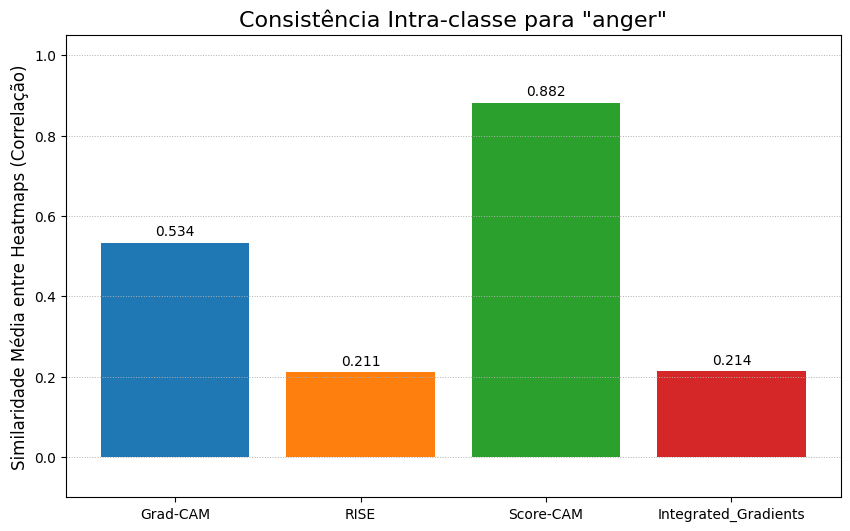



Análise de consistência intra-classe concluída.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from scipy.stats import pearsonr
from itertools import combinations

print("\n--- Definindo Funções para o Teste de Consistência Intra-classe ---")

def calculate_heatmap_similarity(heatmap1, heatmap2):
    h1_flat = heatmap1.flatten()
    h2_flat = heatmap2.flatten()
    if np.std(h1_flat) < 1e-6 or np.std(h2_flat) < 1e-6:
        return 1.0 if np.allclose(h1_flat, h2_flat) else 0.0
    correlation, _ = pearsonr(h1_flat, h2_flat)
    return correlation

def run_intraclass_consistency_test(model, image_cases, class_idx, class_name):
    consistency_scores = {}
    
    xai_methods_to_test = {
        "Grad-CAM": get_gradcam,
        "RISE": get_rise,
        "Score-CAM": get_score_cam,
        "Integrated_Gradients": get_integrated_gradients_fast,
    }
    
    for method_name, method_func in xai_methods_to_test.items():
        print(f"  - Avaliando consistência para: {method_name}")
        
        heatmaps = []
        for case in image_cases:
            img_array = load_and_preprocess_single_image(case['filepath'])
            if method_name in ["Grad-CAM", "Score-CAM"]:
                heatmap = method_func(model, img_array, LAST_CONV_LAYER_NAME, class_index=class_idx)
            else:
                heatmap = method_func(model, img_array, class_index=class_idx)
            heatmaps.append(heatmap)
            
        if len(heatmaps) < 2:
            consistency_scores[method_name] = 0.0
            continue
            
        similarities = []
        for h1, h2 in combinations(heatmaps, 2):
            similarity = calculate_heatmap_similarity(h1, h2)
            similarities.append(similarity)
            
        consistency_scores[method_name] = np.mean(similarities)
        
    return consistency_scores

N_IMAGES_PER_CLASS = 5
N_TOP_CLASSES = 4
top_classes_to_analyze = sorted_performance.index[:N_TOP_CLASSES].tolist()

print(f"\nAnalisando a consistência intra-classe para as {N_TOP_CLASSES} melhores classes: {top_classes_to_analyze}")

for class_name in top_classes_to_analyze:
    print(f"\n===== Executando Teste de Consistência para a Classe: '{class_name}' =====")
    if class_name != top_classes_to_analyze[3]: continue
    class_idx_to_find = class_names_xai.index(class_name)
    example_cases = [case for case in sucessos if case['true_label_idx'] == class_idx_to_find][:N_IMAGES_PER_CLASS]
    
    if len(example_cases) < N_IMAGES_PER_CLASS:
        print(f"AVISO: Foram encontrados apenas {len(example_cases)} exemplos de sucesso para '{class_name}'.")
        if len(example_cases) < 2:
            print("Não há exemplos suficientes para a comparação. Pulando.")
            continue
    
    consistency_scores = run_intraclass_consistency_test(model, example_cases, class_idx_to_find, class_name)
    
    plt.figure(figsize=(10, 6))
    methods = list(consistency_scores.keys())
    scores = list(consistency_scores.values())
    bars = plt.bar(methods, scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    
    plt.title(f'Consistência Intra-classe para "{class_name}"', fontsize=16)
    plt.ylabel('Similaridade Média entre Heatmaps (Correlação)', fontsize=12)
    plt.ylim(-0.1, 1.05)
    plt.grid(axis='y', linestyle=':', linewidth=0.7)
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom')

    save_dir = os.path.join(BASE_OUTPUT_DIR, "Graficos_de_Avaliacao")
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"Intra-Class_Consistency_Test_{class_name}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    print(f"Gráfico de consistência para '{class_name}' salvo com sucesso em: {save_path}")
    plt.show()
    plt.close()

print("\n\nAnálise de consistência intra-classe concluída.")

In [ ]:
import pandas as pd

print("\n--- Selecionando os Casos de Estudo Mais Informativos ---")

analysis_data_with_logits = []
for i in range(len(filepaths)):
    pred_logit = all_logits[i][predicted_labels_treino[i]]
    
    analysis_data_with_logits.append({
        'filepath': filepaths[i],
        'true_label_idx': true_labels[i],
        'pred_label_idx': predicted_labels_corrigido[i],
        'pred_logit': pred_logit,
    })

sucessos_logits = [item for item in analysis_data_with_logits if item['true_label_idx'] == item['pred_label_idx']]
falhas_logits = [item for item in analysis_data_with_logits if item['true_label_idx'] != item['pred_label_idx']]

sucessos_logits.sort(key=lambda x: x['pred_logit'], reverse=True)
falhas_logits.sort(key=lambda x: x['pred_logit'], reverse=True)

print("\n--- MELHORES IMAGENS PARA ANÁLISE ---")

print("\n[1] Sucessos de Alta Confiança (Modelo no seu melhor):")
for item in sucessos_logits[:3]:
    true_name = class_names_xai[item['true_label_idx']]
    print(f"  - Imagem: {os.path.basename(item['filepath'])}, Classe: {true_name}, Confiança (Logit): {item['pred_logit']:.2f}")

print("\n[2] Sucessos de Baixa Confiança (Acertos hesitantes):")
for item in sucessos_logits[-3:]:
    true_name = class_names_xai[item['true_label_idx']]
    print(f"  - Imagem: {os.path.basename(item['filepath'])}, Classe: {true_name}, Confiança (Logit): {item['pred_logit']:.2f}")

print("\n[3] Falhas de Alta Confiança (Erros perigosos):")
for item in falhas_logits[:3]:
    true_name = class_names_xai[item['true_label_idx']]
    pred_name = class_names_xai[item['pred_label_idx']]
    print(f"  - Imagem: {os.path.basename(item['filepath'])}, True: {true_name}, Pred: {pred_name}, Confiança (Logit): {item['pred_logit']:.2f}")

print("\n[4] Falhas de Baixa Confiança (Casos ambíguos):")
for item in falhas_logits[-3:]:
    true_name = class_names_xai[item['true_label_idx']]
    pred_name = class_names_xai[item['pred_label_idx']]
    print(f"  - Imagem: {os.path.basename(item['filepath'])}, True: {true_name}, Pred: {pred_name}, Confiança (Logit): {item['pred_logit']:.2f}")


--- Selecionando os Casos de Estudo Mais Informativos ---

--- MELHORES IMAGENS PARA ANÁLISE ---

[1] Sucessos de Alta Confiança (Modelo no seu melhor):
  - Imagem: fer0033894.png, Classe: contempt, Confiança (Logit): 29.59
  - Imagem: fer0032135.png, Classe: contempt, Confiança (Logit): 29.48
  - Imagem: fer0034934.png, Classe: contempt, Confiança (Logit): 26.00

[2] Sucessos de Baixa Confiança (Acertos hesitantes):
  - Imagem: fer0031118.png, Classe: disgust, Confiança (Logit): -0.29
  - Imagem: fer0031266.png, Classe: disgust, Confiança (Logit): -0.29
  - Imagem: fer0032921.png, Classe: happiness, Confiança (Logit): -0.38

[3] Falhas de Alta Confiança (Erros perigosos):
  - Imagem: fer0033207.png, True: neutral, Pred: contempt, Confiança (Logit): 18.06
  - Imagem: fer0032008.png, True: anger, Pred: disgust, Confiança (Logit): 17.92
  - Imagem: fer0032468.png, True: anger, Pred: disgust, Confiança (Logit): 17.12

[4] Falhas de Baixa Confiança (Casos ambíguos):
  - Imagem: fer0029787


--- Iniciando a Análise de Comportamento Interno do Score-CAM para Todas as Emoções ---

===== Analisando o Comportamento do Score-CAM para a Classe: 'anger' =====


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


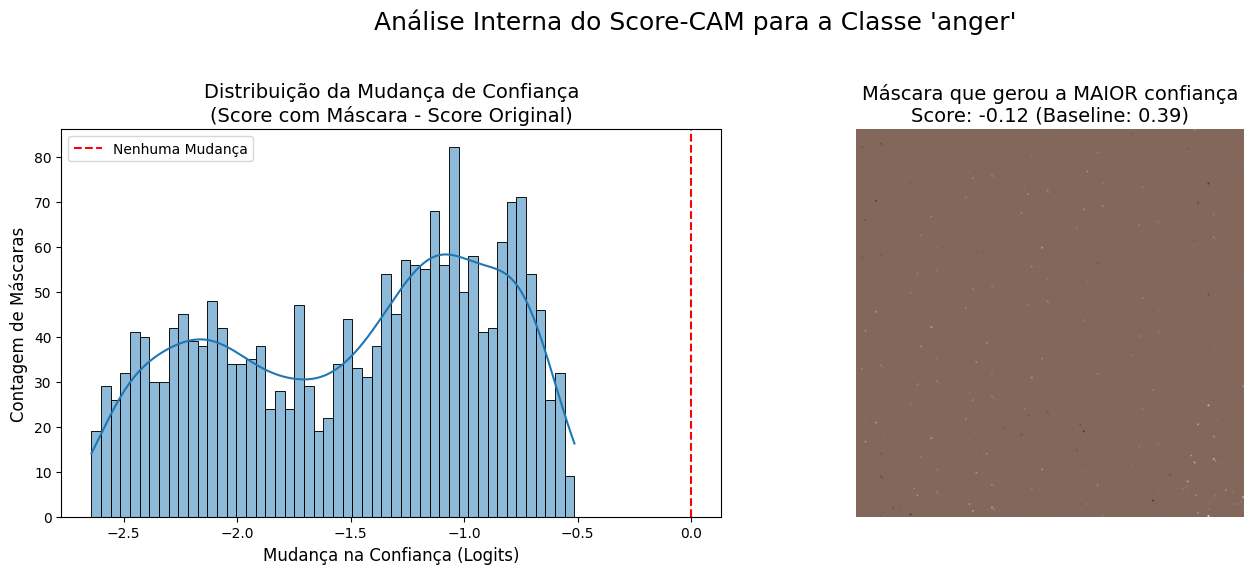


===== Analisando o Comportamento do Score-CAM para a Classe: 'contempt' =====


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


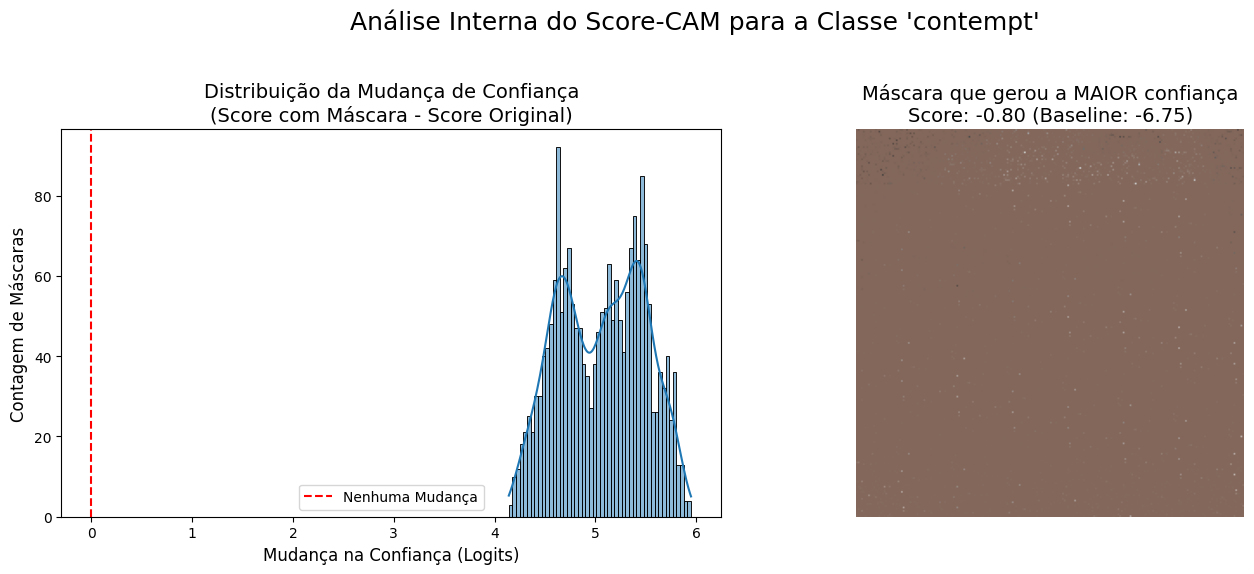


===== Analisando o Comportamento do Score-CAM para a Classe: 'disgust' =====


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


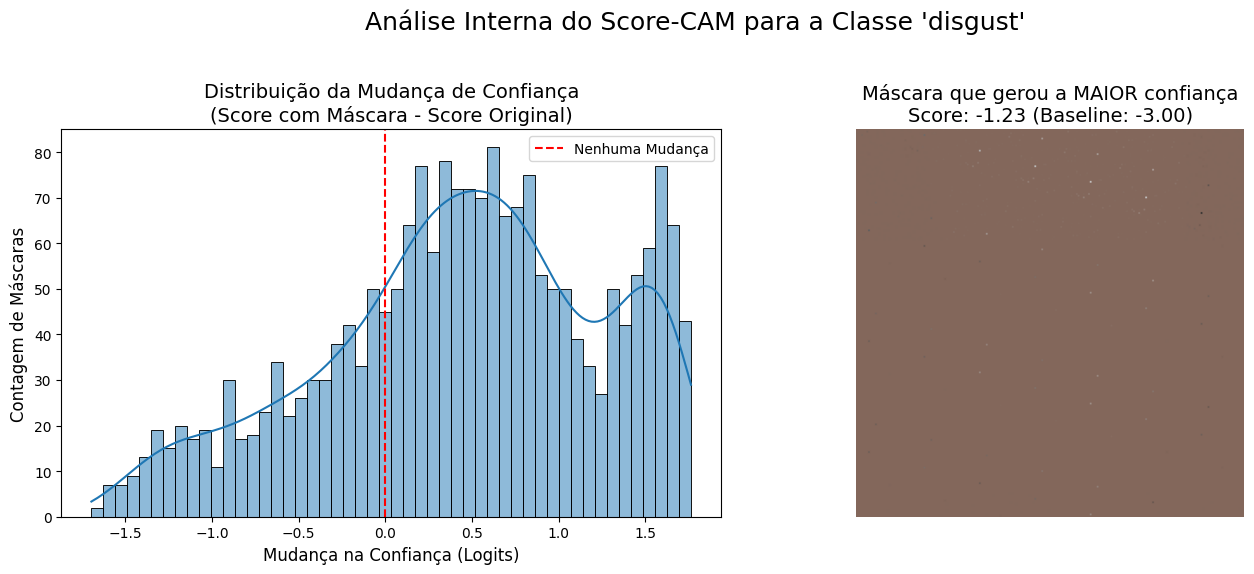


===== Analisando o Comportamento do Score-CAM para a Classe: 'fear' =====


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


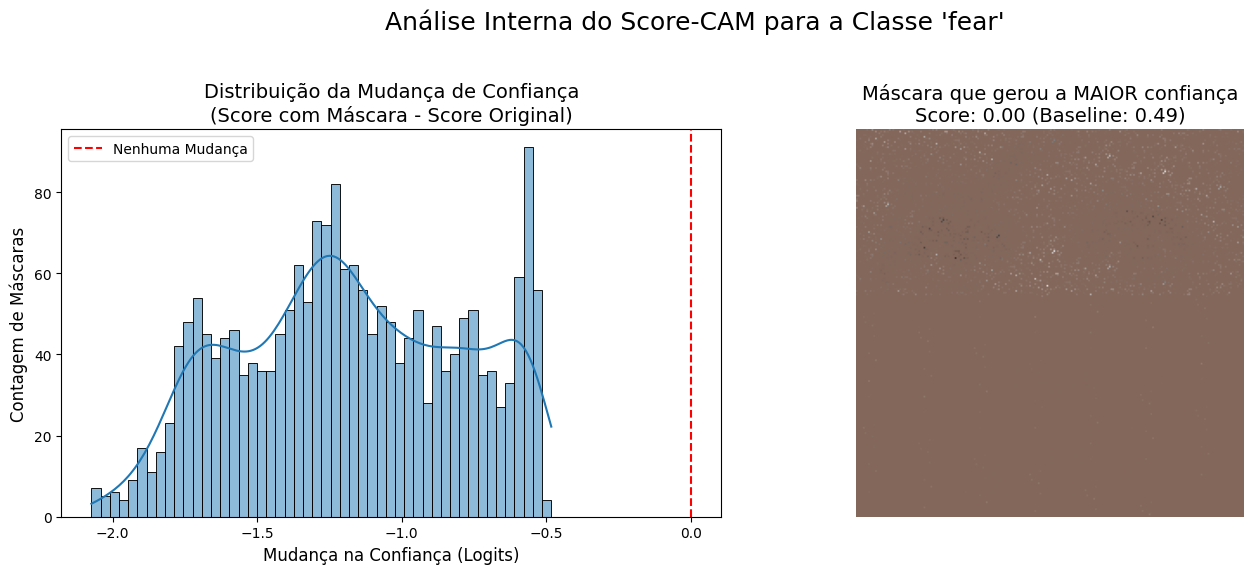


===== Analisando o Comportamento do Score-CAM para a Classe: 'happiness' =====


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


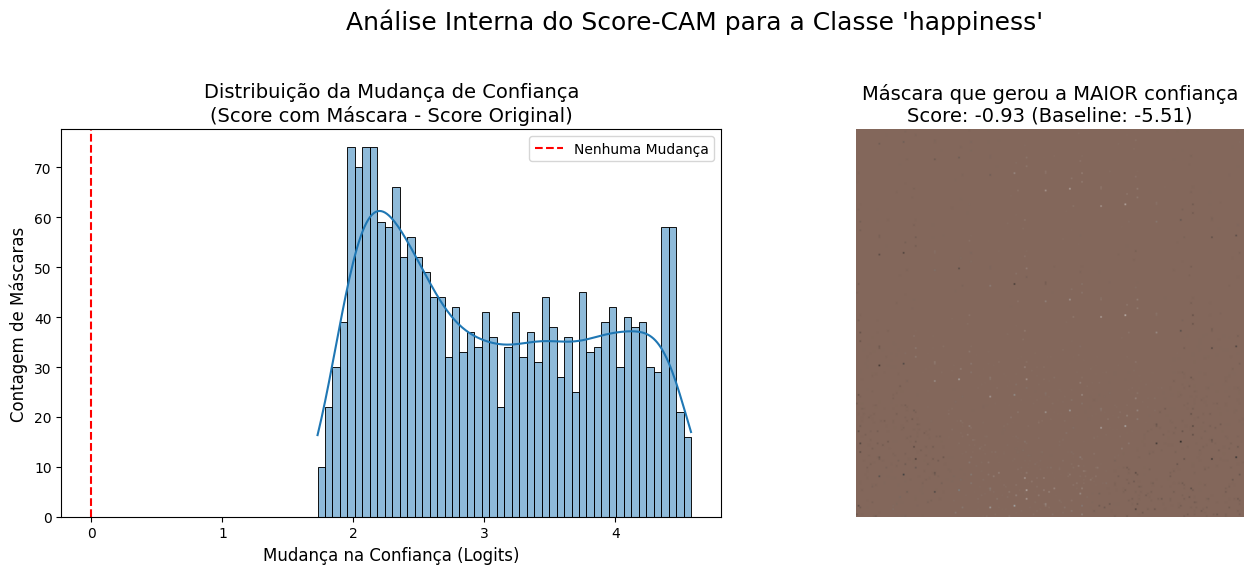


===== Analisando o Comportamento do Score-CAM para a Classe: 'neutral' =====


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


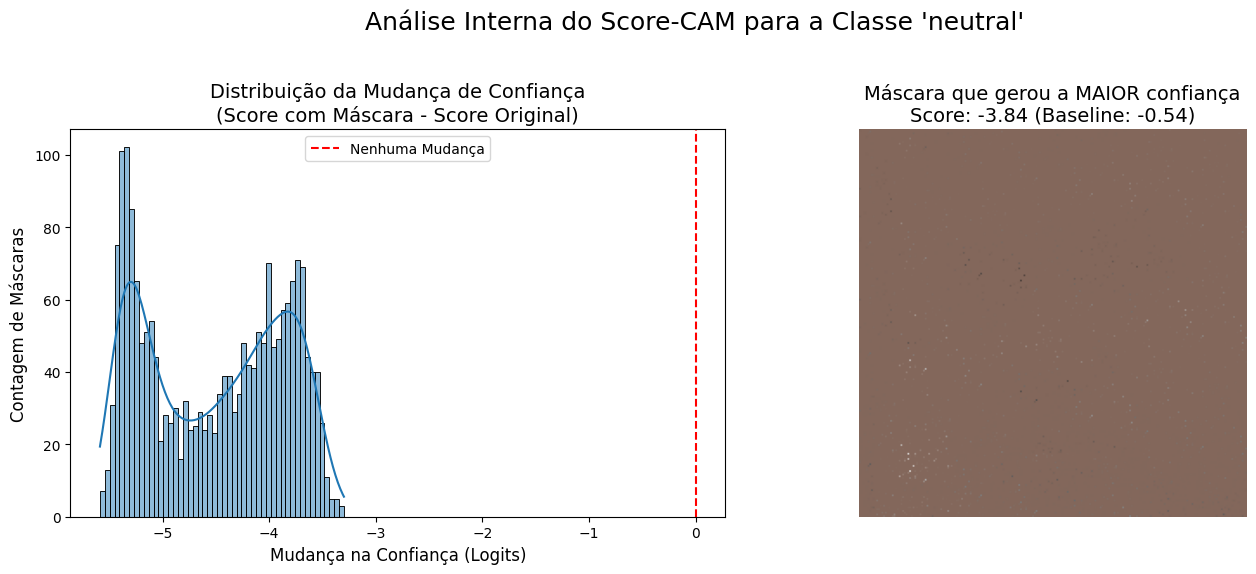


===== Analisando o Comportamento do Score-CAM para a Classe: 'sadness' =====


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


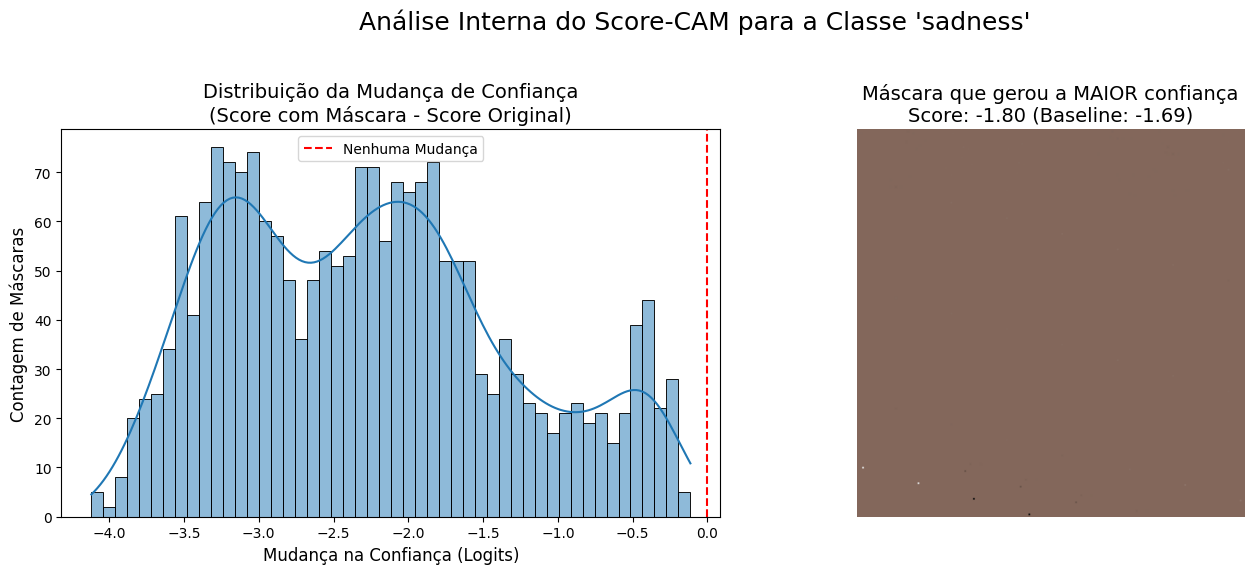


===== Analisando o Comportamento do Score-CAM para a Classe: 'surprise' =====


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


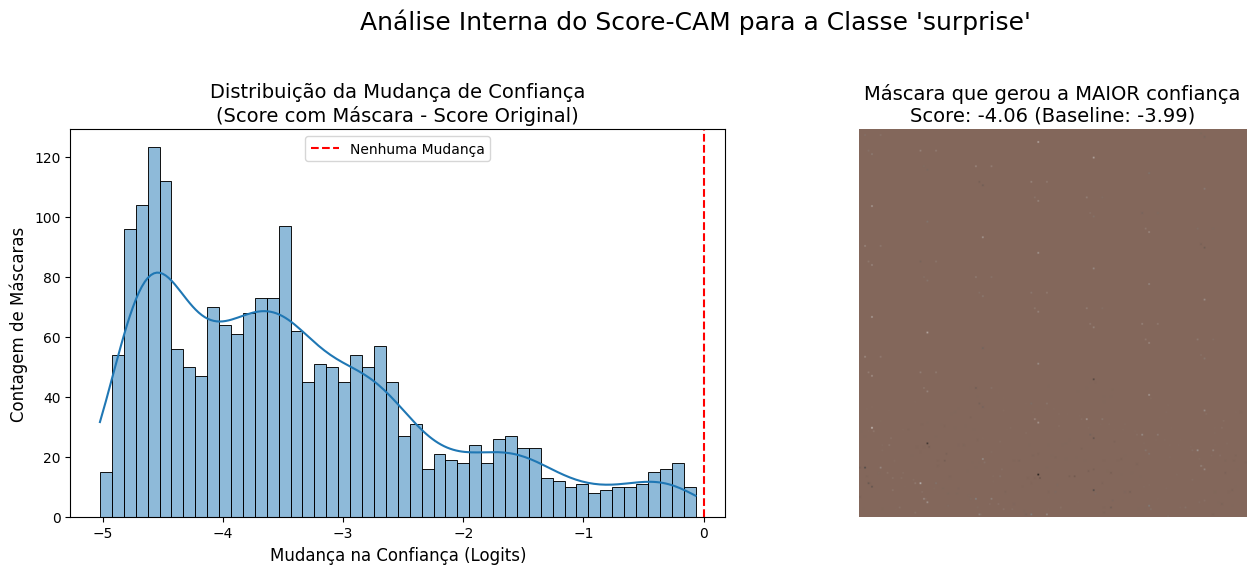



Análise interna do Score-CAM para todas as classes concluída.


In [ ]:
import seaborn as sns

print("\n--- Iniciando a Análise de Comportamento Interno do Score-CAM para Todas as Emoções ---")

def debug_score_cam(model, img_array, layer_name, class_index, class_name_str):
    """
    Executa o Score-CAM passo a passo e visualiza os scores de confiança.
    """
    img_array = tf.cast(img_array, dtype=tf.float32)
    baseline_pred = model.predict(img_array, verbose=0)
    baseline_score = baseline_pred[0][class_index]

    base_model = model.get_layer(BASE_MODEL_NAME)
    conv_output = base_model.get_layer(layer_name).output
    feature_map_model = Model(inputs=base_model.inputs, outputs=conv_output)
    
    feature_maps = feature_map_model.predict(img_array, verbose=0)
    feature_maps = tf.cast(feature_maps, dtype=tf.float32)
    
    masks = tf.image.resize(feature_maps, (IMG_SIZE, IMG_SIZE), method='bilinear')
    masks = tf.reshape(masks, (-1, IMG_SIZE, IMG_SIZE))
    min_vals = tf.reduce_min(masks, axis=[1, 2], keepdims=True)
    max_vals = tf.reduce_max(masks, axis=[1, 2], keepdims=True)
    normalized_masks = (masks - min_vals) / (max_vals - min_vals + 1e-7)
    
    masked_images = tf.expand_dims(img_array[0], axis=0) * tf.expand_dims(normalized_masks, axis=-1)
    
    predictions = model.predict(masked_images, verbose=0)
    scores = predictions[:, class_index]
    
    change_in_scores = scores.astype(np.float32) - baseline_score.astype(np.float32)
    
    best_mask_index = np.argmax(scores)
    best_score = scores[best_mask_index]
    best_mask_image = masked_images[best_mask_index]
    best_mask_display = deprocess_input_vggface(np.expand_dims(best_mask_image, axis=0))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    sns.histplot(change_in_scores, ax=axes[0], bins=50, kde=True)
    axes[0].axvline(0, color='red', linestyle='--', label='Nenhuma Mudança')
    axes[0].set_title('Distribuição da Mudança de Confiança\n(Score com Máscara - Score Original)', fontsize=14)
    axes[0].set_xlabel('Mudança na Confiança (Logits)', fontsize=12)
    axes[0].set_ylabel('Contagem de Máscaras', fontsize=12)
    axes[0].legend()

    axes[1].imshow(best_mask_display, cmap='gray')
    axes[1].set_title(f'Máscara que gerou a MAIOR confiança\nScore: {best_score:.2f} (Baseline: {baseline_score:.2f})', fontsize=14)
    axes[1].axis('off')
    
    plt.suptitle(f"Análise Interna do Score-CAM para a Classe '{class_name_str}'", fontsize=18)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

for class_idx, class_name in enumerate(class_names_xai):
    print(f"\n===== Analisando o Comportamento do Score-CAM para a Classe: '{class_name}' =====")
    
    example_case = None
    for case in sucessos:
        if case['true_label_idx'] == class_idx:
            example_case = case
            break

    if example_case:
        img_array = load_and_preprocess_single_image(example_case['filepath'])
        # Chama a função de depuração para este caso
        debug_score_cam(model, img_array, LAST_CONV_LAYER_NAME, class_idx, class_name)
    else:
        print(f"Não foi encontrado um exemplo de sucesso para '{class_name}' para a depuração.")

print("\n\nAnálise interna do Score-CAM para todas as classes concluída.")


--- Analisando a Confiança Média das Predições por Classe ---

Confiança Média (Logit) para Cada Classe Prevista:
(Valores mais altos indicam maior confiança na decisão)
pred_label_name
contempt     9.250822
disgust      7.176693
surprise     5.398661
anger        4.936811
fear         4.390203
happiness    4.343475
neutral      3.564893
sadness      2.593421
Name: pred_logit, dtype: float32


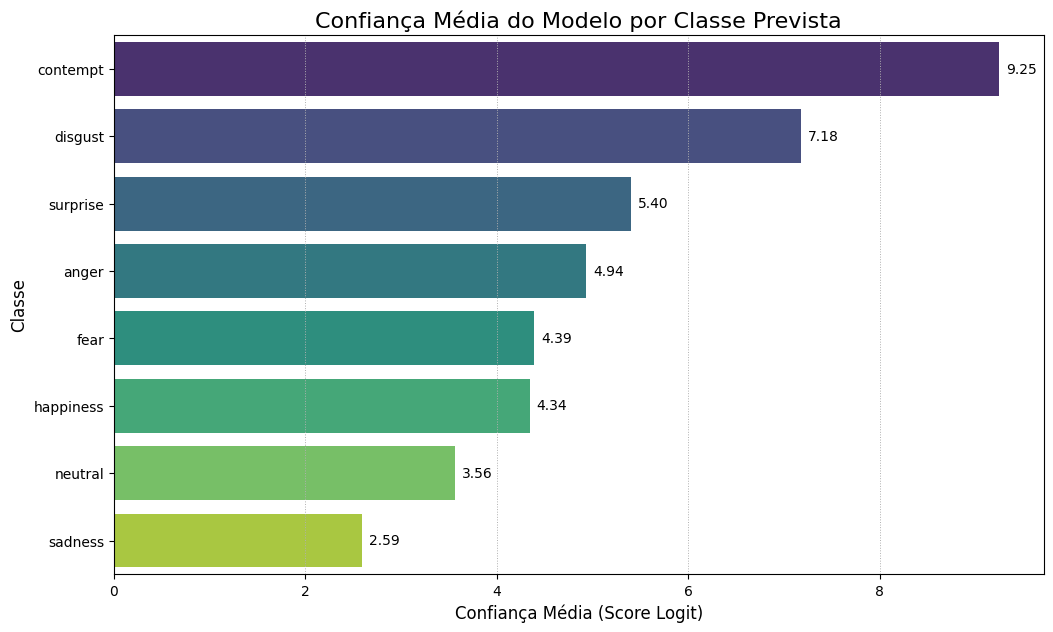

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Analisando a Confiança Média das Predições por Classe ---")

if 'analysis_data_with_logits' not in locals():
    print("ERRO: A lista 'analysis_data_with_logits' não foi encontrada. Execute a célula de 'Seleção Estratégica' primeiro.")
else:
    df_analysis = pd.DataFrame(analysis_data_with_logits)
    
    idx_to_name = {i: name for i, name in enumerate(class_names_xai)}
    df_analysis['pred_label_name'] = df_analysis['pred_label_idx'].map(idx_to_name)

    avg_confidence_by_class = df_analysis.groupby('pred_label_name')['pred_logit'].mean()
    
    sorted_confidence = avg_confidence_by_class.sort_values(ascending=False)

    print("\nConfiança Média (Logit) para Cada Classe Prevista:")
    print("(Valores mais altos indicam maior confiança na decisão)")
    print(sorted_confidence)
    
    plt.figure(figsize=(12, 7))
    
    sorted_confidence_df = sorted_confidence.reset_index()
    sorted_confidence_df.columns = ['Classe Prevista', 'Confiança Média (Logit)']
    
    bars = sns.barplot(
        x='Confiança Média (Logit)', 
        y='Classe Prevista', 
        data=sorted_confidence_df,
        orient='h',
        palette='viridis'
    )
    
    for bar in bars.patches:
        bars.annotate(f'{bar.get_width():.2f}', 
                      (bar.get_width(), bar.get_y() + bar.get_height() / 2),
                      ha='left', va='center',
                      size=10, xytext=(5, 0),
                      textcoords='offset points')

    plt.title('Confiança Média do Modelo por Classe Prevista', fontsize=16)
    plt.xlabel('Confiança Média (Score Logit)', fontsize=12)
    plt.ylabel('Classe', fontsize=12)
    plt.grid(axis='x', linestyle=':', linewidth=0.7)
    plt.show()